# SciPy Exercises XP


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats
from scipy.stats import norm, t, chi2, f, binom
from scipy.stats import pearsonr, spearmanr
from scipy.stats import linregress
from scipy.stats import f_oneway
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully!")
print(f"SciPy version: {scipy.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

All libraries imported successfully!
SciPy version: 1.16.2
NumPy version: 2.3.3
Pandas version: 2.3.3
Matplotlib version: 3.10.7


##  Exercise 1: Basic Usage of SciPy


In [2]:
print("=== EXERCISE 1: Basic Usage of SciPy ===")

import scipy

print(f"SciPy Version: {scipy.__version__}")

print(f"\nSciPy Installation Path: {scipy.__file__}")

#  key submodules
scipy_modules = [
    'scipy.stats',      # Statistical functions
    'scipy.optimize',   # Optimization algorithms
    'scipy.integrate',  # Integration routines
    'scipy.linalg',     # Linear algebra
    'scipy.signal',     # Signal processing
    'scipy.sparse',     # Sparse matrices
    'scipy.spatial',    # Spatial algorithms and data structures
    'scipy.special',    # Special functions
    'scipy.interpolate' # Interpolation
]

print(f"\nKey SciPy Submodules:")
for module in scipy_modules:
    print(f"  • {module}")

from scipy.constants import pi, e, c

print(f"\nSciPy Constants Examples:")
print(f"  π (pi): {pi:.6f}")
print(f"  e (Euler's number): {e:.6f}")
print(f"  c (speed of light): {c:.2e} m/s")

print(f"\n Exercise 1 Complete: SciPy is ready to use!")

=== EXERCISE 1: Basic Usage of SciPy ===
SciPy Version: 1.16.2

SciPy Installation Path: C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\scipy\__init__.py

Key SciPy Submodules:
  • scipy.stats
  • scipy.optimize
  • scipy.integrate
  • scipy.linalg
  • scipy.signal
  • scipy.sparse
  • scipy.spatial
  • scipy.special
  • scipy.interpolate

SciPy Constants Examples:
  π (pi): 3.141593
  e (Euler's number): 0.000000
  c (speed of light): 3.00e+08 m/s

 Exercise 1 Complete: SciPy is ready to use!


##  Exercise 2: Descriptive Statistics


=== EXERCISE 2: Descriptive Statistics ===
Sample Dataset: [12, 15, 13, 12, 18, 20, 22, 21]
Dataset size: 8 values

--- Method 1: Using scipy.stats.describe() ---
Number of observations: 8
Min and Max values: (np.int64(12), np.int64(22))
Mean: 16.6250
Variance: 17.1250
Skewness: 0.0653
Kurtosis: -1.6477

--- Method 2: Individual Calculations ---
Mean: 16.6250
Median: 16.5000
Sample Variance: 17.1250
Sample Standard Deviation: 4.1382
Mode: 12 (appears 2 times)
Interquartile Range (IQR): 7.5000
Percentiles [25th, 50th, 75th]: [12.75 16.5  20.25]


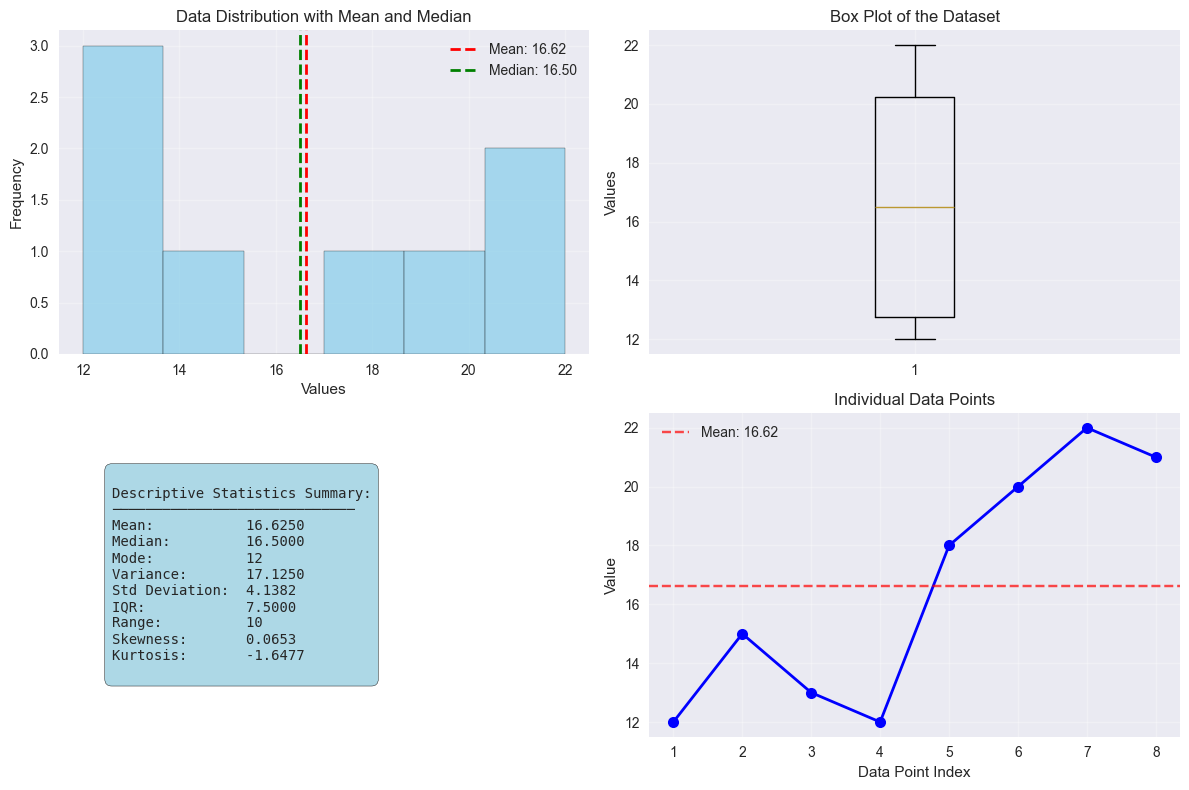


 Exercise 2 Complete: Descriptive statistics calculated and visualized!


In [3]:
print("=== EXERCISE 2: Descriptive Statistics ===")

data = [12, 15, 13, 12, 18, 20, 22, 21]
data_array = np.array(data)

print(f"Sample Dataset: {data}")
print(f"Dataset size: {len(data)} values")

# Calculate descriptive statistics using SciPy and NumPy
from scipy.stats import describe

# Method 1: Using scipy.stats.describe() for comprehensive statistics
desc_stats = describe(data_array)

print(f"\n--- Method 1: Using scipy.stats.describe() ---")
print(f"Number of observations: {desc_stats.nobs}")
print(f"Min and Max values: {desc_stats.minmax}")
print(f"Mean: {desc_stats.mean:.4f}")
print(f"Variance: {desc_stats.variance:.4f}")
print(f"Skewness: {desc_stats.skewness:.4f}")
print(f"Kurtosis: {desc_stats.kurtosis:.4f}")

# Method 2: Individual calculations using SciPy and NumPy
print(f"\n--- Method 2: Individual Calculations ---")

# Mean
mean_val = np.mean(data_array)
print(f"Mean: {mean_val:.4f}")

# Median
median_val = np.median(data_array)
print(f"Median: {median_val:.4f}")

# Variance (using scipy.stats for unbiased estimator)
variance_val = np.var(data_array, ddof=1)  # ddof=1 for sample variance
print(f"Sample Variance: {variance_val:.4f}")

# Standard Deviation
std_val = np.std(data_array, ddof=1)  # ddof=1 for sample standard deviation
print(f"Sample Standard Deviation: {std_val:.4f}")

from scipy.stats import mode, iqr

# Mode
mode_result = mode(data_array, keepdims=True)
if hasattr(mode_result.mode, '__len__') and len(mode_result.mode) > 0:
    print(f"Mode: {mode_result.mode[0]} (appears {mode_result.count[0]} times)")
else:
    print(f"Mode: {mode_result.mode} (appears {mode_result.count} times)")

# Interquartile Range
iqr_val = iqr(data_array)
print(f"Interquartile Range (IQR): {iqr_val:.4f}")

# Percentiles
percentiles = [25, 50, 75]
perc_values = np.percentile(data_array, percentiles)
print(f"Percentiles [25th, 50th, 75th]: {perc_values}")

# Visualization
plt.figure(figsize=(12, 8))

# Subplot 1: Histogram with statistics
plt.subplot(2, 2, 1)
plt.hist(data_array, bins=6, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Data Distribution with Mean and Median')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Box plot
plt.subplot(2, 2, 2)
plt.boxplot(data_array, vert=True)
plt.ylabel('Values')
plt.title('Box Plot of the Dataset')
plt.grid(True, alpha=0.3)

# Subplot 3: Summary statistics table
plt.subplot(2, 2, 3)
plt.axis('off')
stats_text = f"""
Descriptive Statistics Summary:
─────────────────────────────
Mean:           {mean_val:.4f}
Median:         {median_val:.4f}
Mode:           {mode_result.mode[0]}
Variance:       {variance_val:.4f}
Std Deviation:  {std_val:.4f}
IQR:            {iqr_val:.4f}
Range:          {max(data) - min(data)}
Skewness:       {desc_stats.skewness:.4f}
Kurtosis:       {desc_stats.kurtosis:.4f}
"""
plt.text(0.1, 0.5, stats_text, fontsize=10, fontfamily='monospace',
         verticalalignment='center', bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue"))

# Subplot 4: Data points
plt.subplot(2, 2, 4)
plt.plot(range(1, len(data)+1), data_array, 'bo-', linewidth=2, markersize=8)
plt.axhline(mean_val, color='red', linestyle='--', alpha=0.7, label=f'Mean: {mean_val:.2f}')
plt.xlabel('Data Point Index')
plt.ylabel('Value')
plt.title('Individual Data Points')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Exercise 2 Complete: Descriptive statistics calculated and visualized!")

##  Exercise 3: Understanding Distributions


=== EXERCISE 3: Normal Distributions ===
Normal Distribution Parameters:
  Mean (μ): 50
  Standard Deviation (σ): 10

Generated 1000 random samples from normal distribution
Sample mean: 50.19
Sample std: 9.79

Probabilities for Normal Distribution:
  P(μ - σ ≤ X ≤ μ + σ): 0.6827 (≈68%)
  P(μ - 2σ ≤ X ≤ μ + 2σ): 0.9545 (≈95%)
  P(μ - 3σ ≤ X ≤ μ + 3σ): 0.9973 (≈99.7%)


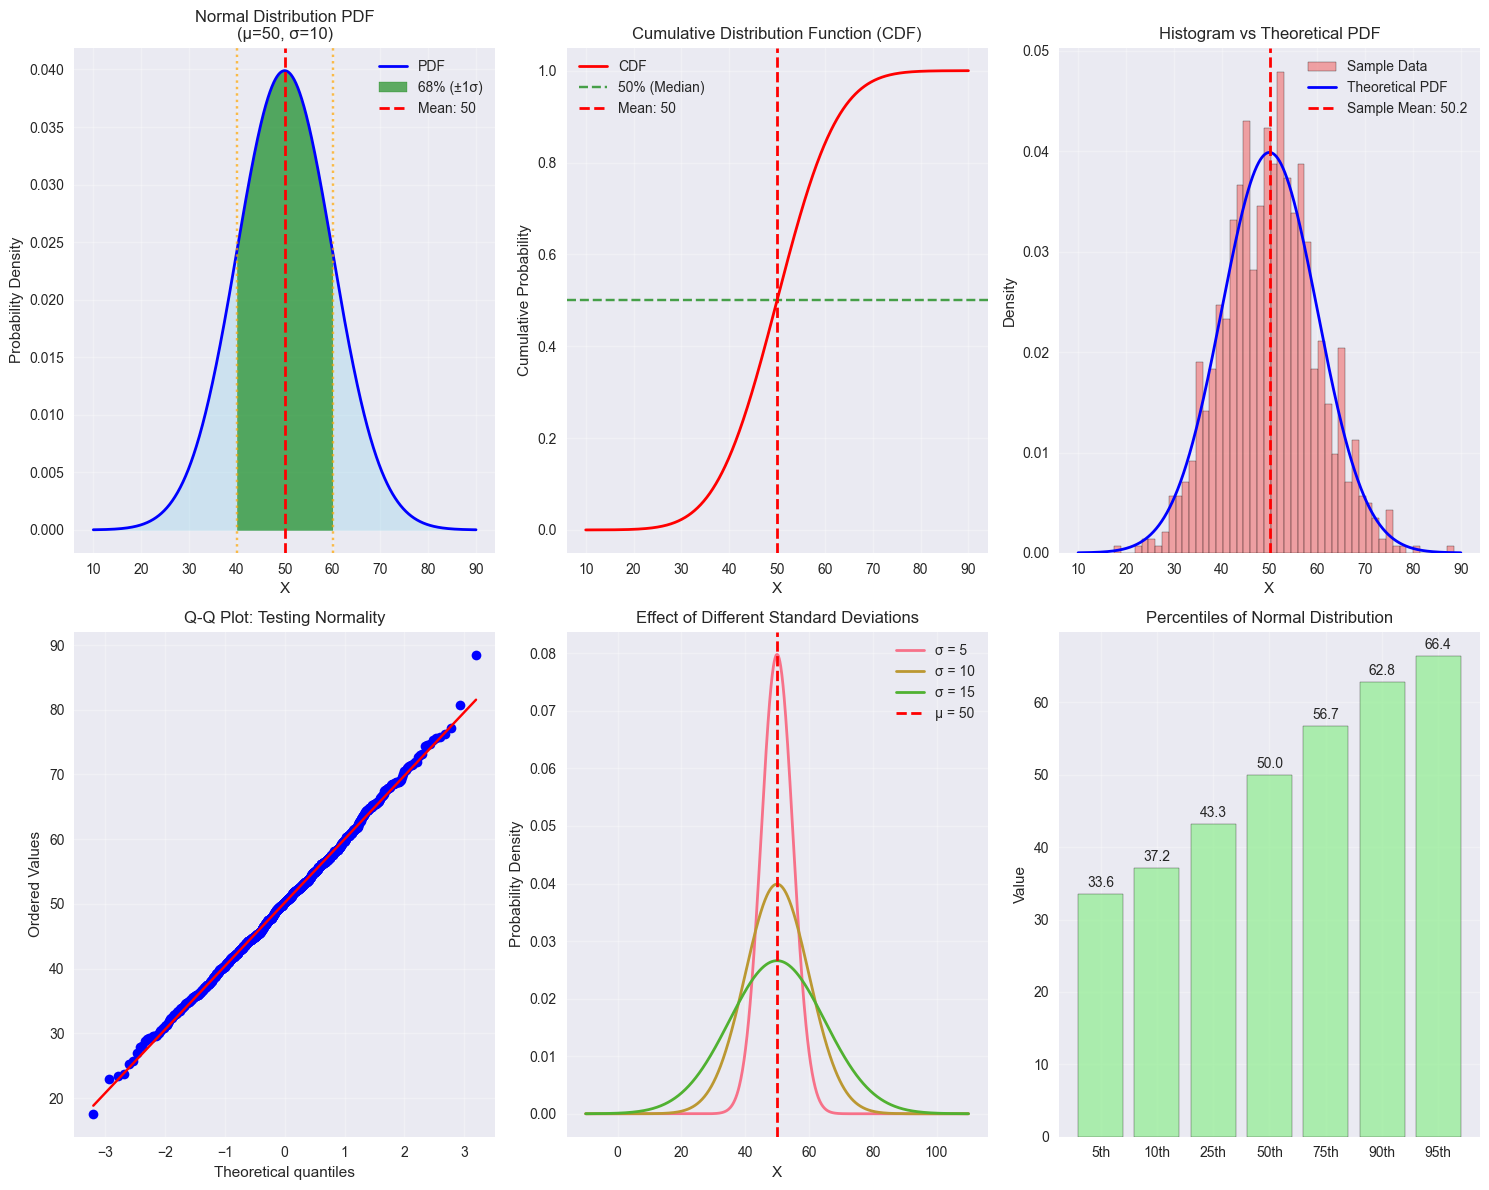


Z-Score Analysis:
  X = 30: Z-score = -2.00, P(X ≤ 30) = 0.0228
  X = 40: Z-score = -1.00, P(X ≤ 40) = 0.1587
  X = 50: Z-score = 0.00, P(X ≤ 50) = 0.5000
  X = 60: Z-score = 1.00, P(X ≤ 60) = 0.8413
  X = 70: Z-score = 2.00, P(X ≤ 70) = 0.9772

 Exercise 3 Complete: Normal distribution generated and analyzed!


In [4]:
# Exercise 3: Normal Distributions
print("=== EXERCISE 3: Normal Distributions ===")

sample_size = 1000  
mean = 50
std_dev = 10  

print(f"Normal Distribution Parameters:")
print(f"  Mean (μ): {mean}")
print(f"  Standard Deviation (σ): {std_dev}")

# Generate normal distribution using SciPy
from scipy.stats import norm

# Method 1: Generate random samples
np.random.seed(42)  
random_samples = norm.rvs(loc=mean, scale=std_dev, size=sample_size)

print(f"\nGenerated {sample_size} random samples from normal distribution")
print(f"Sample mean: {np.mean(random_samples):.2f}")
print(f"Sample std: {np.std(random_samples, ddof=1):.2f}")

# Method 2: Create probability density function (PDF)
x = np.linspace(mean - 4*std_dev, mean + 4*std_dev, 1000)
pdf_values = norm.pdf(x, loc=mean, scale=std_dev)

# Method 3: Create cumulative distribution function (CDF)
cdf_values = norm.cdf(x, loc=mean, scale=std_dev)

# Calculate some probabilities
prob_within_1_std = norm.cdf(mean + std_dev, loc=mean, scale=std_dev) - norm.cdf(mean - std_dev, loc=mean, scale=std_dev)
prob_within_2_std = norm.cdf(mean + 2*std_dev, loc=mean, scale=std_dev) - norm.cdf(mean - 2*std_dev, loc=mean, scale=std_dev)
prob_within_3_std = norm.cdf(mean + 3*std_dev, loc=mean, scale=std_dev) - norm.cdf(mean - 3*std_dev, loc=mean, scale=std_dev)

print(f"\nProbabilities for Normal Distribution:")
print(f"  P(μ - σ ≤ X ≤ μ + σ): {prob_within_1_std:.4f} (≈68%)")
print(f"  P(μ - 2σ ≤ X ≤ μ + 2σ): {prob_within_2_std:.4f} (≈95%)")
print(f"  P(μ - 3σ ≤ X ≤ μ + 3σ): {prob_within_3_std:.4f} (≈99.7%)")

# Visualization
plt.figure(figsize=(15, 12))

# Subplot 1: PDF with shaded areas
plt.subplot(2, 3, 1)
plt.plot(x, pdf_values, 'b-', linewidth=2, label='PDF')
plt.fill_between(x, pdf_values, alpha=0.3, color='skyblue')

# Shade 68% area (1 standard deviation)
mask_1std = (x >= mean - std_dev) & (x <= mean + std_dev)
plt.fill_between(x[mask_1std], pdf_values[mask_1std], alpha=0.6, color='green', label='68% (±1σ)')

plt.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean}')
plt.axvline(mean - std_dev, color='orange', linestyle=':', alpha=0.7)
plt.axvline(mean + std_dev, color='orange', linestyle=':', alpha=0.7)
plt.xlabel('X')
plt.ylabel('Probability Density')
plt.title(f'Normal Distribution PDF\n(μ={mean}, σ={std_dev})')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: CDF
plt.subplot(2, 3, 2)
plt.plot(x, cdf_values, 'r-', linewidth=2, label='CDF')
plt.axhline(0.5, color='green', linestyle='--', alpha=0.7, label='50% (Median)')
plt.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean}')
plt.xlabel('X')
plt.ylabel('Cumulative Probability')
plt.title('Cumulative Distribution Function (CDF)')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 3: Histogram of random samples
plt.subplot(2, 3, 3)
plt.hist(random_samples, bins=50, density=True, alpha=0.7, color='lightcoral', edgecolor='black', label='Sample Data')
plt.plot(x, pdf_values, 'b-', linewidth=2, label='Theoretical PDF')
plt.axvline(np.mean(random_samples), color='red', linestyle='--', linewidth=2, label=f'Sample Mean: {np.mean(random_samples):.1f}')
plt.xlabel('X')
plt.ylabel('Density')
plt.title('Histogram vs Theoretical PDF')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 4: Q-Q plot to check normality
from scipy.stats import probplot
plt.subplot(2, 3, 4)
probplot(random_samples, dist="norm", plot=plt)
plt.title('Q-Q Plot: Testing Normality')
plt.grid(True, alpha=0.3)

# Subplot 5: Multiple normal distributions comparison
plt.subplot(2, 3, 5)
for sigma in [5, 10, 15]:
    x_comp = np.linspace(mean - 4*15, mean + 4*15, 1000)
    pdf_comp = norm.pdf(x_comp, loc=mean, scale=sigma)
    plt.plot(x_comp, pdf_comp, linewidth=2, label=f'σ = {sigma}')

plt.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'μ = {mean}')
plt.xlabel('X')
plt.ylabel('Probability Density')
plt.title('Effect of Different Standard Deviations')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 6: Percentiles and critical values
plt.subplot(2, 3, 6)
percentiles_list = [5, 10, 25, 50, 75, 90, 95]
percentile_values = norm.ppf([p/100 for p in percentiles_list], loc=mean, scale=std_dev)

plt.bar(range(len(percentiles_list)), percentile_values, color='lightgreen', alpha=0.7, edgecolor='black')
plt.xticks(range(len(percentiles_list)), [f'{p}th' for p in percentiles_list])
plt.ylabel('Value')
plt.title('Percentiles of Normal Distribution')
plt.grid(True, alpha=0.3)

# Add value labels on bars
for i, v in enumerate(percentile_values):
    plt.text(i, v + 0.5, f'{v:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Additional analysis: Z-scores
print(f"\nZ-Score Analysis:")
test_values = [30, 40, 50, 60, 70]
for val in test_values:
    z_score = (val - mean) / std_dev
    prob = norm.cdf(val, loc=mean, scale=std_dev)
    print(f"  X = {val}: Z-score = {z_score:.2f}, P(X ≤ {val}) = {prob:.4f}")

print(f"\n Exercise 3 Complete: Normal distribution generated and analyzed!")

## Exercise 4: T-Test Application


Dataset 1: Normal(μ=50, σ=10), n=100
Dataset 2: Normal(μ=60, σ=10), n=100

Descriptive Statistics:
Data 1 - Mean: 48.962, Std: 9.082
Data 2 - Mean: 60.223, Std: 9.537

1. TWO-SAMPLE INDEPENDENT T-TEST
Null Hypothesis (H₀): μ₁ = μ₂ (means are equal)
Alternative Hypothesis (H₁): μ₁ ≠ μ₂ (means are different)

Assuming Equal Variances:
  T-statistic: -8.5515
  P-value: 0.000000
  Degrees of freedom: 198

Welch's T-test (Unequal Variances):
  T-statistic: -8.5515
  P-value: 0.000000

2. ONE-SAMPLE T-TESTS
Data1 vs μ=50:
  T-statistic: -1.1435, P-value: 0.255600
Data2 vs μ=60:
  T-statistic: 0.2339, P-value: 0.815560

3. EFFECT SIZE ANALYSIS
Cohen's d: -1.2094
Effect size interpretation: large

4. CONFIDENCE INTERVAL
95% CI for difference in means: [-13.858, -8.665]

5. STATISTICAL INTERPRETATION (α = 0.05)
Decision: Reject H₀
Conclusion: There is significant evidence that the means are different


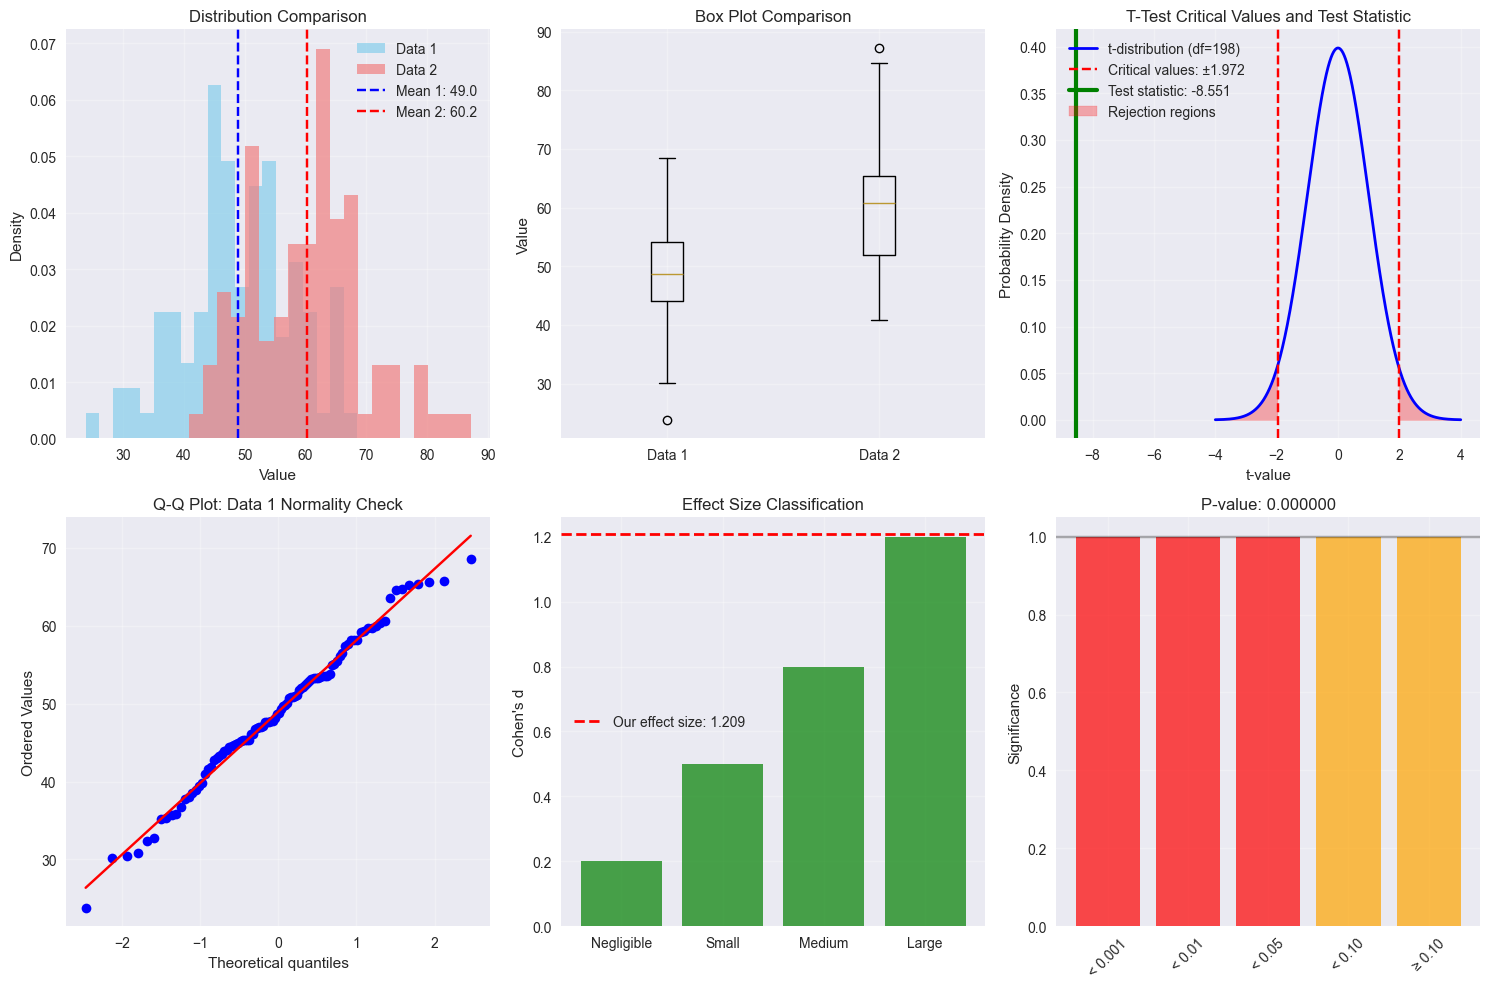

In [6]:
# Generate the datasets as specified
np.random.seed(42)  # For reproducibility
data1 = np.random.normal(50, 10, 100)
data2 = np.random.normal(60, 10, 100)

print(f"Dataset 1: Normal(μ=50, σ=10), n=100")
print(f"Dataset 2: Normal(μ=60, σ=10), n=100")

# Calculate descriptive statistics for both datasets
print(f"\nDescriptive Statistics:")
print(f"Data 1 - Mean: {np.mean(data1):.3f}, Std: {np.std(data1, ddof=1):.3f}")
print(f"Data 2 - Mean: {np.mean(data2):.3f}, Std: {np.std(data2, ddof=1):.3f}")

# Perform different types of t-tests
from scipy.stats import ttest_ind, ttest_rel, ttest_1samp

# 1. Two-sample independent t-test (most common)
print(f"\n1. TWO-SAMPLE INDEPENDENT T-TEST")
print(f"Null Hypothesis (H₀): μ₁ = μ₂ (means are equal)")
print(f"Alternative Hypothesis (H₁): μ₁ ≠ μ₂ (means are different)")

# Assuming equal variances
t_stat_equal, p_value_equal = ttest_ind(data1, data2, equal_var=True)
print(f"\nAssuming Equal Variances:")
print(f"  T-statistic: {t_stat_equal:.4f}")
print(f"  P-value: {p_value_equal:.6f}")
print(f"  Degrees of freedom: {len(data1) + len(data2) - 2}")

# Not assuming equal variances (Welch's t-test)
t_stat_unequal, p_value_unequal = ttest_ind(data1, data2, equal_var=False)
print(f"\nWelch's T-test (Unequal Variances):")
print(f"  T-statistic: {t_stat_unequal:.4f}")
print(f"  P-value: {p_value_unequal:.6f}")

# 2. One-sample t-tests
print(f"\n2. ONE-SAMPLE T-TESTS")

# Test if data1 mean is significantly different from 50
t_stat_1samp_1, p_value_1samp_1 = ttest_1samp(data1, 50)
print(f"Data1 vs μ=50:")
print(f"  T-statistic: {t_stat_1samp_1:.4f}, P-value: {p_value_1samp_1:.6f}")

# Test if data2 mean is significantly different from 60
t_stat_1samp_2, p_value_1samp_2 = ttest_1samp(data2, 60)
print(f"Data2 vs μ=60:")
print(f"  T-statistic: {t_stat_1samp_2:.4f}, P-value: {p_value_1samp_2:.6f}")

# 3. Effect size calculation (Cohen's d)
def cohens_d(group1, group2):
    """Calculate Cohen's d for effect size"""
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    
    # Pooled standard deviation
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    
    # Cohen's d
    d = (np.mean(group1) - np.mean(group2)) / pooled_std
    return d

effect_size = cohens_d(data1, data2)
print(f"\n3. EFFECT SIZE ANALYSIS")
print(f"Cohen's d: {effect_size:.4f}")

# Interpret effect size
if abs(effect_size) < 0.2:
    effect_interpretation = "negligible"
elif abs(effect_size) < 0.5:
    effect_interpretation = "small"
elif abs(effect_size) < 0.8:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"

print(f"Effect size interpretation: {effect_interpretation}")

# 4. Confidence intervals
from scipy.stats import t as t_dist

confidence_level = 0.95
alpha = 1 - confidence_level

# Confidence interval for the difference in means
mean_diff = np.mean(data1) - np.mean(data2)
se_diff = np.sqrt(np.var(data1, ddof=1)/len(data1) + np.var(data2, ddof=1)/len(data2))
df = len(data1) + len(data2) - 2
t_critical = t_dist.ppf(1 - alpha/2, df)

ci_lower = mean_diff - t_critical * se_diff
ci_upper = mean_diff + t_critical * se_diff

print(f"\n4. CONFIDENCE INTERVAL")
print(f"95% CI for difference in means: [{ci_lower:.3f}, {ci_upper:.3f}]")

# Statistical interpretation
alpha_level = 0.05
print(f"\n5. STATISTICAL INTERPRETATION (α = {alpha_level})")

if p_value_unequal < alpha_level:
    decision = "Reject H₀"
    conclusion = "There is significant evidence that the means are different"
else:
    decision = "Fail to reject H₀"
    conclusion = "There is insufficient evidence that the means are different"

print(f"Decision: {decision}")
print(f"Conclusion: {conclusion}")

# Visualization
plt.figure(figsize=(15, 10))

# Subplot 1: Histograms of both datasets
plt.subplot(2, 3, 1)
plt.hist(data1, bins=20, alpha=0.7, label='Data 1', color='skyblue', density=True)
plt.hist(data2, bins=20, alpha=0.7, label='Data 2', color='lightcoral', density=True)
plt.axvline(np.mean(data1), color='blue', linestyle='--', label=f'Mean 1: {np.mean(data1):.1f}')
plt.axvline(np.mean(data2), color='red', linestyle='--', label=f'Mean 2: {np.mean(data2):.1f}')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Distribution Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Box plots
plt.subplot(2, 3, 2)
plt.boxplot([data1, data2], labels=['Data 1', 'Data 2'])
plt.ylabel('Value')
plt.title('Box Plot Comparison')
plt.grid(True, alpha=0.3)

# Subplot 3: T-distribution with critical values
plt.subplot(2, 3, 3)
x_t = np.linspace(-4, 4, 1000)
y_t = t_dist.pdf(x_t, df)
plt.plot(x_t, y_t, 'b-', linewidth=2, label=f't-distribution (df={df})')

# Shade critical regions
critical_neg = -t_critical
critical_pos = t_critical
plt.axvline(critical_neg, color='red', linestyle='--', label=f'Critical values: ±{t_critical:.3f}')
plt.axvline(critical_pos, color='red', linestyle='--')
plt.axvline(t_stat_unequal, color='green', linewidth=3, label=f'Test statistic: {t_stat_unequal:.3f}')

# Shade rejection regions
x_left = x_t[x_t <= critical_neg]
x_right = x_t[x_t >= critical_pos]
plt.fill_between(x_left, t_dist.pdf(x_left, df), alpha=0.3, color='red', label='Rejection regions')
plt.fill_between(x_right, t_dist.pdf(x_right, df), alpha=0.3, color='red')

plt.xlabel('t-value')
plt.ylabel('Probability Density')
plt.title('T-Test Critical Values and Test Statistic')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 4: Q-Q plots for normality check
plt.subplot(2, 3, 4)
probplot(data1, dist="norm", plot=plt)
plt.title('Q-Q Plot: Data 1 Normality Check')
plt.grid(True, alpha=0.3)

# Subplot 5: Effect size visualization
plt.subplot(2, 3, 5)
effect_sizes = ['Negligible', 'Small', 'Medium', 'Large']
effect_thresholds = [0.2, 0.5, 0.8, 1.2]
colors = ['green' if abs(effect_size) >= thresh else 'lightgray' for thresh in [0, 0.2, 0.5, 0.8]]

plt.bar(effect_sizes, effect_thresholds, color=colors, alpha=0.7)
plt.axhline(abs(effect_size), color='red', linestyle='--', linewidth=2, 
            label=f'Our effect size: {abs(effect_size):.3f}')
plt.ylabel("Cohen's d")
plt.title('Effect Size Classification')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 6: P-value interpretation
plt.subplot(2, 3, 6)
p_categories = ['< 0.001', '< 0.01', '< 0.05', '< 0.10', '≥ 0.10']
p_thresholds = [0.001, 0.01, 0.05, 0.10, 1.0]
colors_p = []

for thresh in p_thresholds:
    if p_value_unequal < thresh:
        colors_p.append('red' if thresh <= 0.05 else 'orange')
    else:
        colors_p.append('lightgray')

plt.bar(p_categories, [1]*5, color=colors_p, alpha=0.7)
plt.axhline(1, color='black', linestyle='-', alpha=0.3)
plt.ylabel('Significance')
plt.title(f'P-value: {p_value_unequal:.6f}')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Exercise 5: Linear Regression Analysis


=== EXERCISE 5: Linear Regression ===
Dataset:
House Sizes (m²): [ 50  70  80 100 120]
House Prices: [150000 200000 210000 250000 280000]
Number of data points: 5

=== LINEAR REGRESSION RESULTS ===
1. Slope (β₁): 1828.77
2. Intercept (β₀): 64383.56
3. Correlation coefficient (r): 0.9942
4. R-squared (r²): 0.9884
5. P-value: 0.000531
6. Standard error: 114.27
Slope: 1828.77 currency units per square meter
Intercept: 64383.56 currency units
Regression equation: Price = 64383.56 + 1828.77 × Size

=== QUESTION 2: Prediction for 90 m² ===
Predicted price for 90 m²: 228,972.60 currency units
The slope (1828.77) means:
• For every additional square meter, the house price increases by 1,828.77 currency units
• This represents the marginal effect of house size on price
• The relationship is positive

=== ADDITIONAL STATISTICAL ANALYSIS ===
Predictions vs Actual:
  50 m²: Actual = 150,000, Predicted = 155,822, Residual = -5,822
  70 m²: Actual = 200,000, Predicted = 192,397, Residual = 7,603
  8

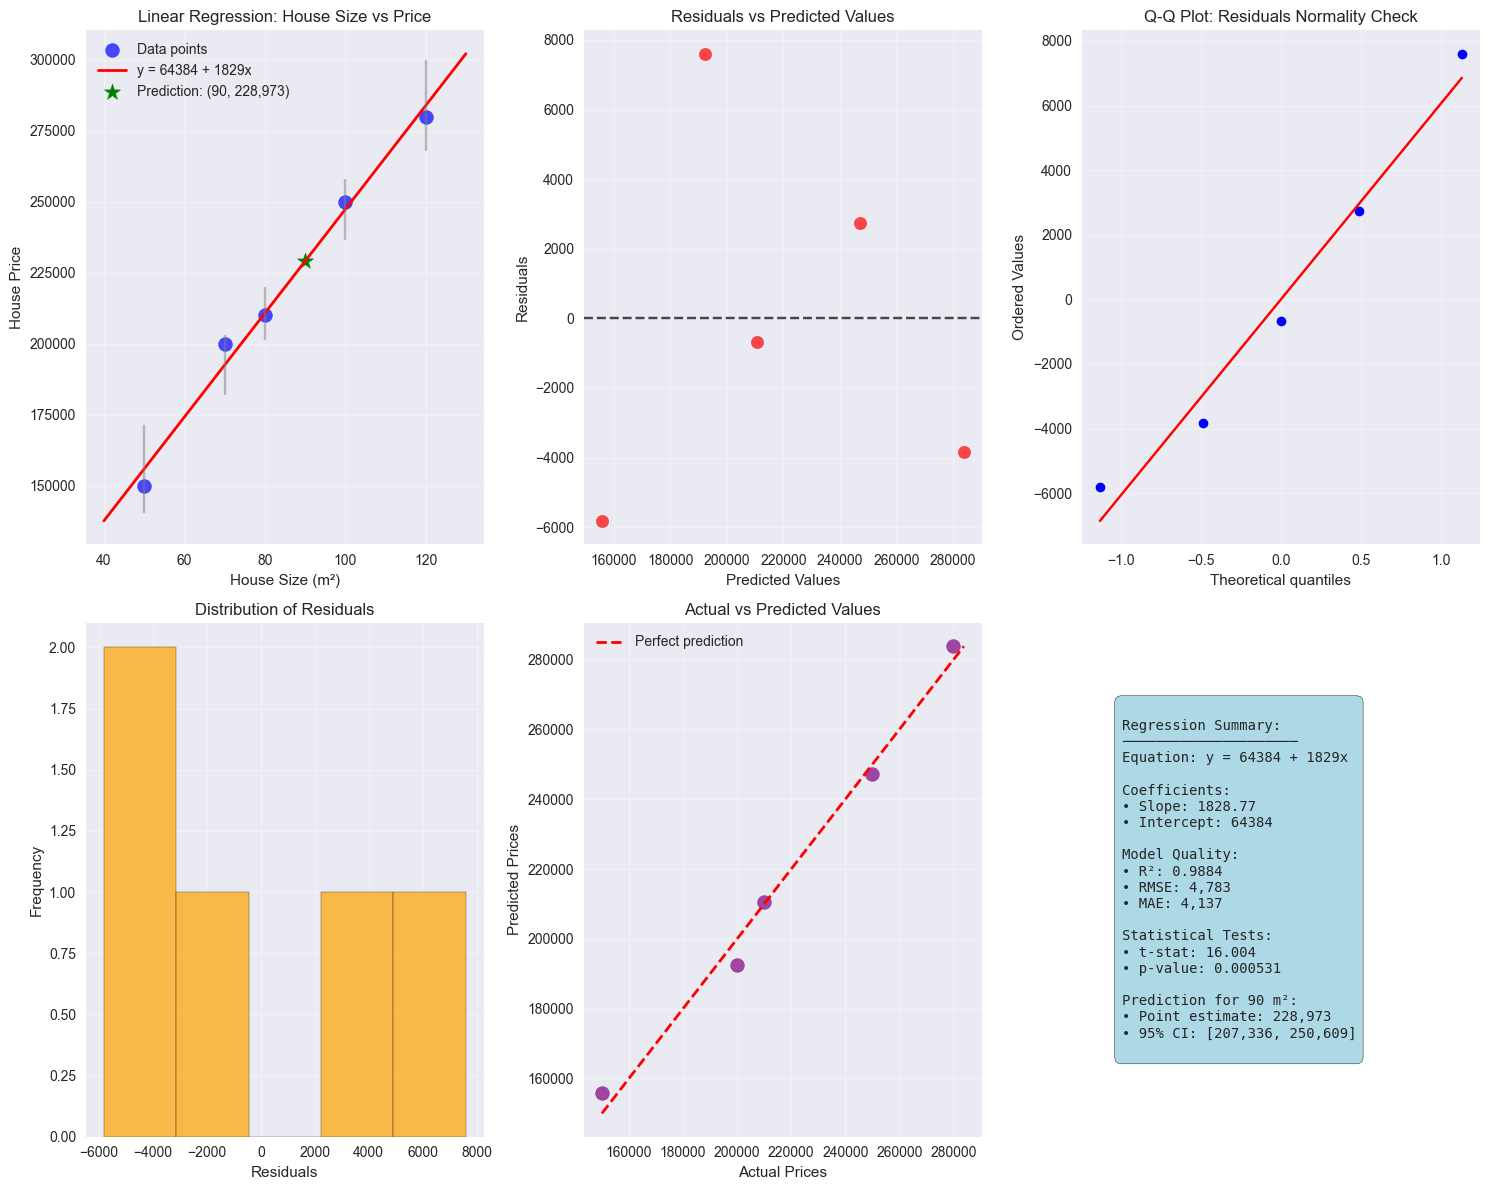


=== ADDITIONAL PREDICTIONS ===
Price predictions for different house sizes:
  60 m²: 174,110 currency units
  75 m²: 201,541 currency units
  90 m²: 228,973 currency units
  110 m²: 265,548 currency units
  130 m²: 302,123 currency units

✅ Exercise 5 Complete: Linear regression analysis performed with comprehensive interpretation!


In [7]:
# Exercise 5: Linear Regression
print("=== EXERCISE 5: Linear Regression ===")

# Import required libraries for this exercise
from scipy.stats import probplot

house_sizes = np.array([50, 70, 80, 100, 120])  # in square meters
house_prices = np.array([150000, 200000, 210000, 250000, 280000])  # in currency units

print(f"Dataset:")
print(f"House Sizes (m²): {house_sizes}")
print(f"House Prices: {house_prices}")
print(f"Number of data points: {len(house_sizes)}")

# Perform linear regression using SciPy
slope, intercept, r_value, p_value, std_err = linregress(house_sizes, house_prices)

print(f"\n=== LINEAR REGRESSION RESULTS ===")
print(f"1. Slope (β₁): {slope:.2f}")
print(f"2. Intercept (β₀): {intercept:.2f}")
print(f"3. Correlation coefficient (r): {r_value:.4f}")
print(f"4. R-squared (r²): {r_value**2:.4f}")
print(f"5. P-value: {p_value:.6f}")
print(f"6. Standard error: {std_err:.2f}")

# Slope and Intercept
print(f"Slope: {slope:.2f} currency units per square meter")
print(f"Intercept: {intercept:.2f} currency units")
print(f"Regression equation: Price = {intercept:.2f} + {slope:.2f} × Size")

#  Predict price for 90 square meters
target_size = 90
predicted_price = intercept + slope * target_size

print(f"\n=== QUESTION 2: Prediction for 90 m² ===")
print(f"Predicted price for {target_size} m²: {predicted_price:,.2f} currency units")

# Interpret the slope
print(f"The slope ({slope:.2f}) means:")
print(f"• For every additional square meter, the house price increases by {slope:,.2f} currency units")
print(f"• This represents the marginal effect of house size on price")
print(f"• The relationship is {'positive' if slope > 0 else 'negative'}")

# Additional statistical analysis
print(f"\n=== ADDITIONAL STATISTICAL ANALYSIS ===")

# Calculate residuals
predicted_prices = intercept + slope * house_sizes
residuals = house_prices - predicted_prices

print(f"Predictions vs Actual:")
for i, (size, actual, pred) in enumerate(zip(house_sizes, house_prices, predicted_prices)):
    residual = actual - pred
    print(f"  {size} m²: Actual = {actual:,}, Predicted = {pred:,.0f}, Residual = {residual:,.0f}")

# Model quality metrics
mse = np.mean(residuals**2)  # Mean Squared Error
rmse = np.sqrt(mse)  # Root Mean Squared Error
mae = np.mean(np.abs(residuals))  # Mean Absolute Error

print(f"\nModel Quality Metrics:")
print(f"  Mean Squared Error (MSE): {mse:,.0f}")
print(f"  Root Mean Squared Error (RMSE): {rmse:,.0f}")
print(f"  Mean Absolute Error (MAE): {mae:,.0f}")
print(f"  R-squared: {r_value**2:.4f} ({r_value**2*100:.1f}% of variance explained)")

# Confidence intervals for predictions
from scipy.stats import t

n = len(house_sizes)
df = n - 2  # degrees of freedom
alpha = 0.05  # for 95% confidence interval
t_critical = t.ppf(1 - alpha/2, df)

# Standard error of prediction
x_mean = np.mean(house_sizes)
sxx = np.sum((house_sizes - x_mean)**2)
s_res = np.sqrt(np.sum(residuals**2) / df)  # residual standard error

# Confidence interval for 90 m² prediction
se_pred = s_res * np.sqrt(1 + 1/n + (target_size - x_mean)**2/sxx)
ci_lower = predicted_price - t_critical * se_pred
ci_upper = predicted_price + t_critical * se_pred

print(f"\n95% Confidence Interval for {target_size} m² prediction:")
print(f"  [{ci_lower:,.0f}, {ci_upper:,.0f}] currency units")

t_stat = slope / std_err
print(f"\nHypothesis Test for Slope:")
print(f"  H₀: β₁ = 0 (no relationship)")
print(f"  H₁: β₁ ≠ 0 (significant relationship)")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.6f}")
print(f"  Result: {'Significant' if p_value < 0.05 else 'Not significant'} at α = 0.05")

plt.figure(figsize=(15, 12))

# Subplot 1: Scatter plot with regression line
plt.subplot(2, 3, 1)
plt.scatter(house_sizes, house_prices, color='blue', s=100, alpha=0.7, label='Data points')
x_line = np.linspace(house_sizes.min() - 10, house_sizes.max() + 10, 100)
y_line = intercept + slope * x_line
plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'y = {intercept:.0f} + {slope:.0f}x')

# Highlight the prediction point
plt.scatter(target_size, predicted_price, color='green', s=150, marker='*', 
           label=f'Prediction: ({target_size}, {predicted_price:,.0f})')

plt.xlabel('House Size (m²)')
plt.ylabel('House Price')
plt.title('Linear Regression: House Size vs Price')
plt.legend()
plt.grid(True, alpha=0.3)

# Add confidence interval
for i, (x, y) in enumerate(zip(house_sizes, house_prices)):
    se_fit = s_res * np.sqrt(1/n + (x - x_mean)**2/sxx)
    ci_fit_lower = predicted_prices[i] - t_critical * se_fit
    ci_fit_upper = predicted_prices[i] + t_critical * se_fit
    plt.plot([x, x], [ci_fit_lower, ci_fit_upper], 'gray', alpha=0.5)

# Subplot 2: Residuals plot
plt.subplot(2, 3, 2)
plt.scatter(predicted_prices, residuals, color='red', s=80, alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.7)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.grid(True, alpha=0.3)

# Subplot 3: Q-Q plot of residuals
plt.subplot(2, 3, 3)
probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot: Residuals Normality Check')
plt.grid(True, alpha=0.3)

# Subplot 4: Histogram of residuals
plt.subplot(2, 3, 4)
plt.hist(residuals, bins=5, alpha=0.7, color='orange', edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.grid(True, alpha=0.3)

# Subplot 5: Actual vs Predicted
plt.subplot(2, 3, 5)
plt.scatter(house_prices, predicted_prices, color='purple', s=100, alpha=0.7)
min_val = min(house_prices.min(), predicted_prices.min())
max_val = max(house_prices.max(), predicted_prices.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 6: Model summary statistics
plt.subplot(2, 3, 6)
plt.axis('off')
summary_text = f"""
Regression Summary:
─────────────────────
Equation: y = {intercept:.0f} + {slope:.0f}x

Coefficients:
• Slope: {slope:.2f}
• Intercept: {intercept:.0f}

Model Quality:
• R²: {r_value**2:.4f}
• RMSE: {rmse:,.0f}
• MAE: {mae:,.0f}

Statistical Tests:
• t-stat: {t_stat:.3f}
• p-value: {p_value:.6f}

Prediction for 90 m²:
• Point estimate: {predicted_price:,.0f}
• 95% CI: [{ci_lower:,.0f}, {ci_upper:,.0f}]
"""

plt.text(0.1, 0.5, summary_text, fontsize=10, fontfamily='monospace',
         verticalalignment='center', bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue"))

plt.tight_layout()
plt.show()

# Additional predictions for different house sizes
print(f"\n=== ADDITIONAL PREDICTIONS ===")
test_sizes = [60, 75, 90, 110, 130]
print(f"Price predictions for different house sizes:")
for size in test_sizes:
    pred_price = intercept + slope * size
    print(f"  {size} m²: {pred_price:,.0f} currency units")

print(f"\n✅ Exercise 5 Complete: Linear regression analysis performed with comprehensive interpretation!")

##  Exercise 6: Understanding ANOVA


Dataset:
Fertilizer 1: [5 6 7 6 5] cm
Fertilizer 2: [7 8 7 9 8] cm
Fertilizer 3: [4 5 4 3 4] cm

=== DESCRIPTIVE STATISTICS ===
Fertilizer 1:
  Mean: 5.80 cm
  Std Dev: 0.84 cm
  Sample Size: 5
  Min: 5 cm, Max: 7 cm
Fertilizer 2:
  Mean: 7.80 cm
  Std Dev: 0.84 cm
  Sample Size: 5
  Min: 7 cm, Max: 9 cm
Fertilizer 3:
  Mean: 4.00 cm
  Std Dev: 0.71 cm
  Sample Size: 5
  Min: 3 cm, Max: 5 cm

=== ANOVA RESULTS ===
1. F-statistic: 28.5263
2. P-value: 0.000028

=== QUESTION 1: ANOVA Test Results ===
F-value: 28.5263
P-value: 0.000028
Significance level (α): 0.05
P-value: 0.000028
Decision: Reject the null hypothesis (H₀)
Conclusion: YES - The fertilizers have significantly different effects on plant growth
If the P-value were greater than 0.05:
• We would fail to reject the null hypothesis
• We would conclude there is insufficient evidence of differences between fertilizers
• The observed differences could be due to random variation
• We cannot claim the fertilizers have different effect

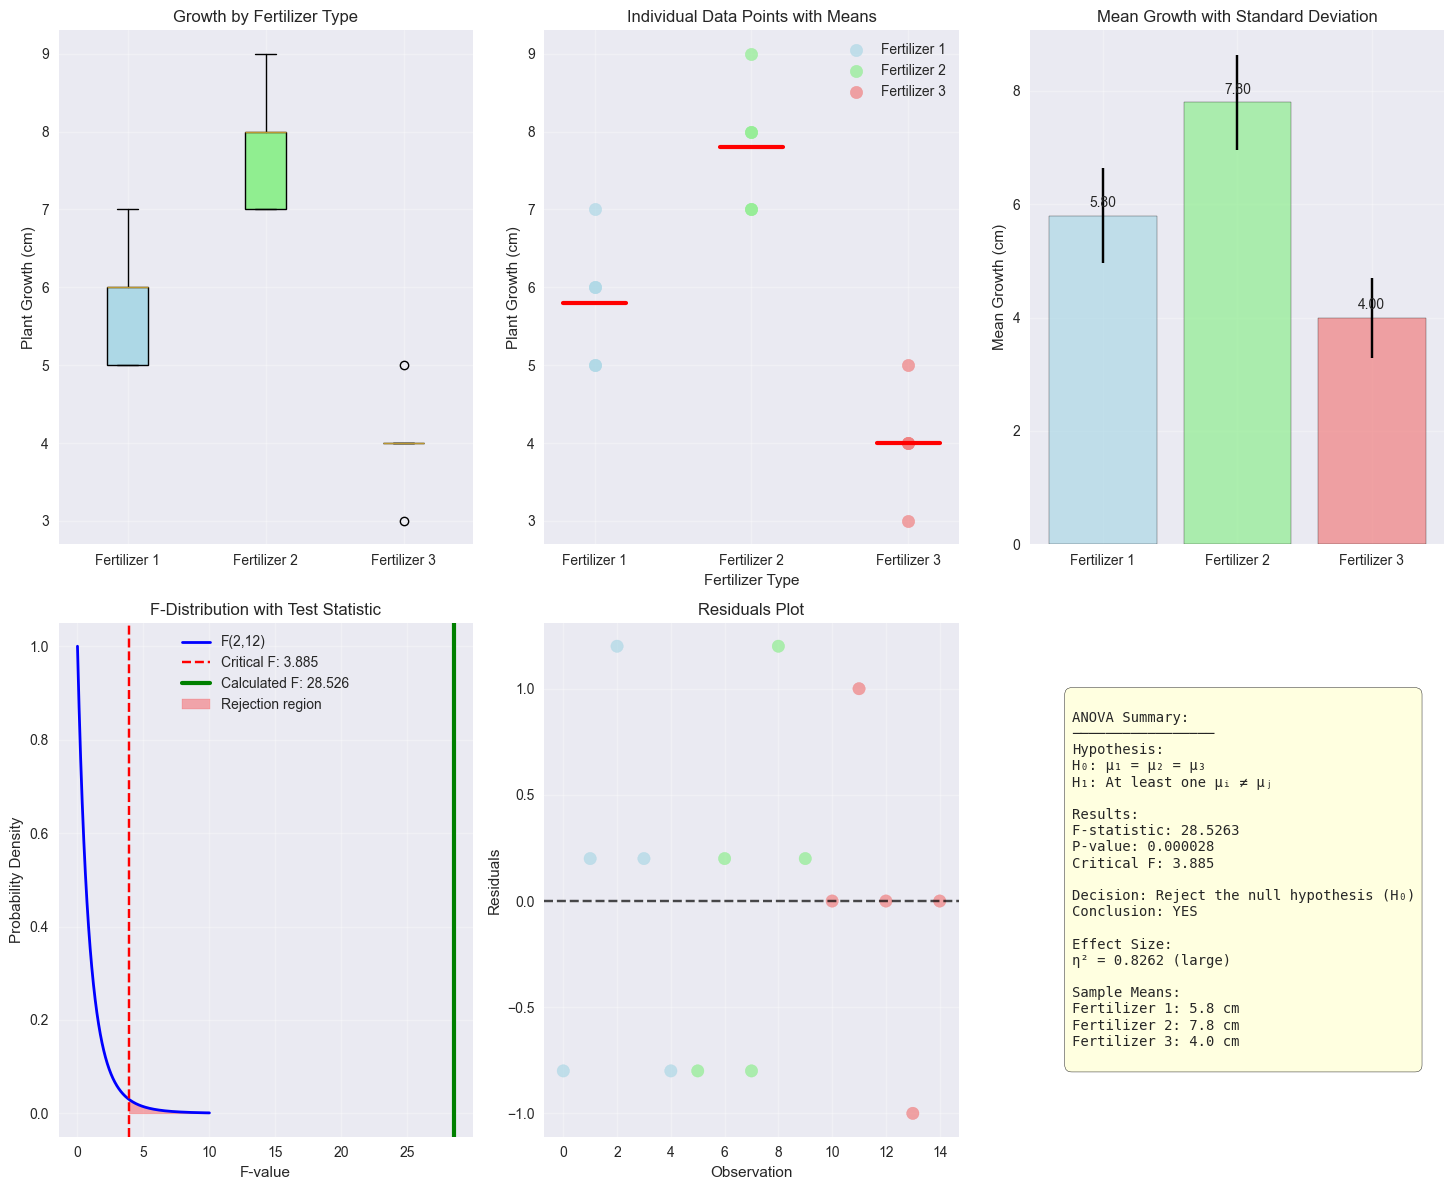


 Exercise 6 Complete: ANOVA analysis performed with comprehensive interpretation!


In [8]:
fertilizer_1 = np.array([5, 6, 7, 6, 5])
fertilizer_2 = np.array([7, 8, 7, 9, 8])
fertilizer_3 = np.array([4, 5, 4, 3, 4])

print(f"Dataset:")
print(f"Fertilizer 1: {fertilizer_1} cm")
print(f"Fertilizer 2: {fertilizer_2} cm")
print(f"Fertilizer 3: {fertilizer_3} cm")

# Calculate descriptive statistics for each group
groups = [fertilizer_1, fertilizer_2, fertilizer_3]
group_names = ['Fertilizer 1', 'Fertilizer 2', 'Fertilizer 3']

print(f"\n=== DESCRIPTIVE STATISTICS ===")
for i, (group, name) in enumerate(zip(groups, group_names)):
    print(f"{name}:")
    print(f"  Mean: {np.mean(group):.2f} cm")
    print(f"  Std Dev: {np.std(group, ddof=1):.2f} cm")
    print(f"  Sample Size: {len(group)}")
    print(f"  Min: {np.min(group)} cm, Max: {np.max(group)} cm")

# Perform One-Way ANOVA using SciPy
f_statistic, p_value = f_oneway(fertilizer_1, fertilizer_2, fertilizer_3)

print(f"\n=== ANOVA RESULTS ===")
print(f"1. F-statistic: {f_statistic:.4f}")
print(f"2. P-value: {p_value:.6f}")

# Answer to Question 1
print(f"\n=== QUESTION 1: ANOVA Test Results ===")
print(f"F-value: {f_statistic:.4f}")
print(f"P-value: {p_value:.6f}")

# Statistical Significance
alpha = 0.05

print(f"Significance level (α): {alpha}")
print(f"P-value: {p_value:.6f}")

if p_value < alpha:
    conclusion = "YES - The fertilizers have significantly different effects on plant growth"
    decision = "Reject the null hypothesis (H₀)"
else:
    conclusion = "NO - The fertilizers do not have significantly different effects on plant growth"
    decision = "Fail to reject the null hypothesis (H₀)"

print(f"Decision: {decision}")
print(f"Conclusion: {conclusion}")


print(f"If the P-value were greater than 0.05:")
print(f"• We would fail to reject the null hypothesis")
print(f"• We would conclude there is insufficient evidence of differences between fertilizers")
print(f"• The observed differences could be due to random variation")
print(f"• We cannot claim the fertilizers have different effects on plant growth")
print(f"• Type II error risk: we might miss a real difference (false negative)")

# Manual ANOVA calculations for educational purposes
print(f"\n=== MANUAL ANOVA CALCULATIONS ===")

# Combine all data
all_data = np.concatenate([fertilizer_1, fertilizer_2, fertilizer_3])
overall_mean = np.mean(all_data)
n_total = len(all_data)

# Group means and sizes
group_means = [np.mean(group) for group in groups]
group_sizes = [len(group) for group in groups]

print(f"Overall mean: {overall_mean:.3f}")
print(f"Group means: {[f'{mean:.3f}' for mean in group_means]}")
print(f"Group sizes: {group_sizes}")

# Sum of Squares calculations
# Between-group sum of squares (SSB)
ssb = sum(n * (mean - overall_mean)**2 for n, mean in zip(group_sizes, group_means))

# Within-group sum of squares (SSW)
ssw = sum(sum((x - group_mean)**2 for x in group) 
          for group, group_mean in zip(groups, group_means))

# Total sum of squares (SST)
sst = sum((x - overall_mean)**2 for x in all_data)

# Degrees of freedom
k = len(groups)  # number of groups
df_between = k - 1
df_within = n_total - k
df_total = n_total - 1

# Mean squares
msb = ssb / df_between
msw = ssw / df_within

# F-statistic
f_calculated = msb / msw

print(f"\nANOVA Table:")
print(f"{'Source':<12} {'SS':<10} {'df':<5} {'MS':<10} {'F':<10}")
print(f"{'-'*50}")
print(f"{'Between':<12} {ssb:<10.3f} {df_between:<5} {msb:<10.3f} {f_calculated:<10.3f}")
print(f"{'Within':<12} {ssw:<10.3f} {df_within:<5} {msw:<10.3f}")
print(f"{'Total':<12} {sst:<10.3f} {df_total:<5}")

# Effect size (Eta-squared)
eta_squared = ssb / sst
print(f"\nEffect Size:")
print(f"Eta-squared (η²): {eta_squared:.4f}")
print(f"Interpretation: {eta_squared*100:.1f}% of variance explained by fertilizer type")

# Effect size interpretation
if eta_squared < 0.01:
    effect_size_interp = "negligible"
elif eta_squared < 0.06:
    effect_size_interp = "small"
elif eta_squared < 0.14:
    effect_size_interp = "medium"
else:
    effect_size_interp = "large"

print(f"Effect size magnitude: {effect_size_interp}")

# Post-hoc analysis (if significant)
if p_value < alpha:
    print(f"\n=== POST-HOC ANALYSIS ===")
    print(f"Since ANOVA is significant, we can perform pairwise comparisons:")
    
    # Pairwise t-tests with Bonferroni correction
    from scipy.stats import ttest_ind
    
    pairs = [(0, 1, 'Fert1 vs Fert2'), 
             (0, 2, 'Fert1 vs Fert3'), 
             (1, 2, 'Fert2 vs Fert3')]
    
    bonferroni_alpha = alpha / len(pairs)
    print(f"Bonferroni-corrected α: {bonferroni_alpha:.4f}")
    
    for i, j, name in pairs:
        t_stat, p_val = ttest_ind(groups[i], groups[j])
        significant = "Yes" if p_val < bonferroni_alpha else "No"
        print(f"{name}: t = {t_stat:.3f}, p = {p_val:.4f}, Significant: {significant}")

# Assumption checks
print(f"\n=== ANOVA ASSUMPTIONS CHECK ===")

# 1. Normality check (Shapiro-Wilk test)
from scipy.stats import shapiro

print(f"1. Normality Test (Shapiro-Wilk):")
for i, (group, name) in enumerate(zip(groups, group_names)):
    stat, p_norm = shapiro(group)
    normal = "Yes" if p_norm > 0.05 else "No"
    print(f"   {name}: W = {stat:.4f}, p = {p_norm:.4f}, Normal: {normal}")

# 2. Homogeneity of variances (Levene's test)
from scipy.stats import levene

levene_stat, levene_p = levene(fertilizer_1, fertilizer_2, fertilizer_3)
equal_var = "Yes" if levene_p > 0.05 else "No"
print(f"2. Equal Variances (Levene's test): F = {levene_stat:.4f}, p = {levene_p:.4f}, Equal: {equal_var}")

# 3. Independence (assumed based on experimental design)
print(f"3. Independence: Assumed based on experimental design")

# Visualization
plt.figure(figsize=(15, 12))

# Subplot 1: Box plots
plt.subplot(2, 3, 1)
data_for_box = [fertilizer_1, fertilizer_2, fertilizer_3]
box_plot = plt.boxplot(data_for_box, labels=group_names, patch_artist=True)
colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)

plt.ylabel('Plant Growth (cm)')
plt.title('Growth by Fertilizer Type')
plt.grid(True, alpha=0.3)

# Subplot 2: Individual data points with means
plt.subplot(2, 3, 2)
for i, (group, name, color) in enumerate(zip(groups, group_names, colors)):
    x_pos = [i+1] * len(group)
    plt.scatter(x_pos, group, color=color, s=80, alpha=0.7, label=name)
    plt.plot([i+0.8, i+1.2], [np.mean(group), np.mean(group)], 'r-', linewidth=3)

plt.ylabel('Plant Growth (cm)')
plt.xlabel('Fertilizer Type')
plt.title('Individual Data Points with Means')
plt.xticks([1, 2, 3], group_names)
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 3: Means with error bars
plt.subplot(2, 3, 3)
means = [np.mean(group) for group in groups]
stds = [np.std(group, ddof=1) for group in groups]
bars = plt.bar(group_names, means, color=colors, alpha=0.7, 
               yerr=stds, capsize=10, edgecolor='black')
plt.ylabel('Mean Growth (cm)')
plt.title('Mean Growth with Standard Deviation')
plt.grid(True, alpha=0.3)

# Add value labels on bars
for bar, mean in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{mean:.2f}', ha='center', va='bottom')

# Subplot 4: F-distribution with critical value
plt.subplot(2, 3, 4)
x_f = np.linspace(0, 10, 1000)
y_f = f.pdf(x_f, df_between, df_within)
plt.plot(x_f, y_f, 'b-', linewidth=2, label=f'F({df_between},{df_within})')

# Critical F-value
f_critical = f.ppf(1 - alpha, df_between, df_within)
plt.axvline(f_critical, color='red', linestyle='--', label=f'Critical F: {f_critical:.3f}')
plt.axvline(f_statistic, color='green', linewidth=3, label=f'Calculated F: {f_statistic:.3f}')

# Shade rejection region
x_reject = x_f[x_f >= f_critical]
plt.fill_between(x_reject, f.pdf(x_reject, df_between, df_within), 
                alpha=0.3, color='red', label='Rejection region')

plt.xlabel('F-value')
plt.ylabel('Probability Density')
plt.title('F-Distribution with Test Statistic')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 5: Residuals analysis
plt.subplot(2, 3, 5)
all_residuals = []
group_labels = []

for i, (group, mean) in enumerate(zip(groups, group_means)):
    residuals = group - mean
    all_residuals.extend(residuals)
    group_labels.extend([group_names[i]] * len(residuals))

residuals_array = np.array(all_residuals)
plt.scatter(range(len(all_residuals)), residuals_array, 
           c=[colors[group_names.index(label)] for label in group_labels], s=80, alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.7)
plt.xlabel('Observation')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.grid(True, alpha=0.3)

# Subplot 6: Summary statistics table
plt.subplot(2, 3, 6)
plt.axis('off')
summary_text = f"""
ANOVA Summary:
─────────────────
Hypothesis:
H₀: μ₁ = μ₂ = μ₃
H₁: At least one μᵢ ≠ μⱼ

Results:
F-statistic: {f_statistic:.4f}
P-value: {p_value:.6f}
Critical F: {f_critical:.3f}

Decision: {decision}
Conclusion: {conclusion.split(' - ')[0]}

Effect Size:
η² = {eta_squared:.4f} ({effect_size_interp})

Sample Means:
Fertilizer 1: {np.mean(fertilizer_1):.1f} cm
Fertilizer 2: {np.mean(fertilizer_2):.1f} cm  
Fertilizer 3: {np.mean(fertilizer_3):.1f} cm
"""

plt.text(0.1, 0.5, summary_text, fontsize=10, fontfamily='monospace',
         verticalalignment='center', bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow"))

plt.tight_layout()
plt.show()

print(f"\n Exercise 6 Complete: ANOVA analysis performed with comprehensive interpretation!")

##  Exercise 7: Probability Distributions (Optional)


Binomial Distribution Parameters:
Number of trials (n): 10
Probability of success (p): 0.5
Example: 10 coin flips, P(heads) = 0.5

=== MAIN CALCULATION ===
P(exactly 5 heads in 10 flips) = 0.246094
As percentage: 24.61%

=== COMPREHENSIVE PROBABILITY ANALYSIS ===
Probability Mass Function (PMF):
  P(X =  0) = 0.000977 ( 0.10%)
  P(X =  1) = 0.009766 ( 0.98%)
  P(X =  2) = 0.043945 ( 4.39%)
  P(X =  3) = 0.117187 (11.72%)
  P(X =  4) = 0.205078 (20.51%)
  P(X =  5) = 0.246094 (24.61%)
  P(X =  6) = 0.205078 (20.51%)
  P(X =  7) = 0.117187 (11.72%)
  P(X =  8) = 0.043945 ( 4.39%)
  P(X =  9) = 0.009766 ( 0.98%)
  P(X = 10) = 0.000977 ( 0.10%)

Cumulative Distribution Function (CDF):
  P(X ≤  0) = 0.000977 ( 0.10%)
  P(X ≤  1) = 0.010742 ( 1.07%)
  P(X ≤  2) = 0.054688 ( 5.47%)
  P(X ≤  3) = 0.171875 (17.19%)
  P(X ≤  4) = 0.376953 (37.70%)
  P(X ≤  5) = 0.623047 (62.30%)
  P(X ≤  6) = 0.828125 (82.81%)
  P(X ≤  7) = 0.945312 (94.53%)
  P(X ≤  8) = 0.989258 (98.93%)
  P(X ≤  9) = 0.999023

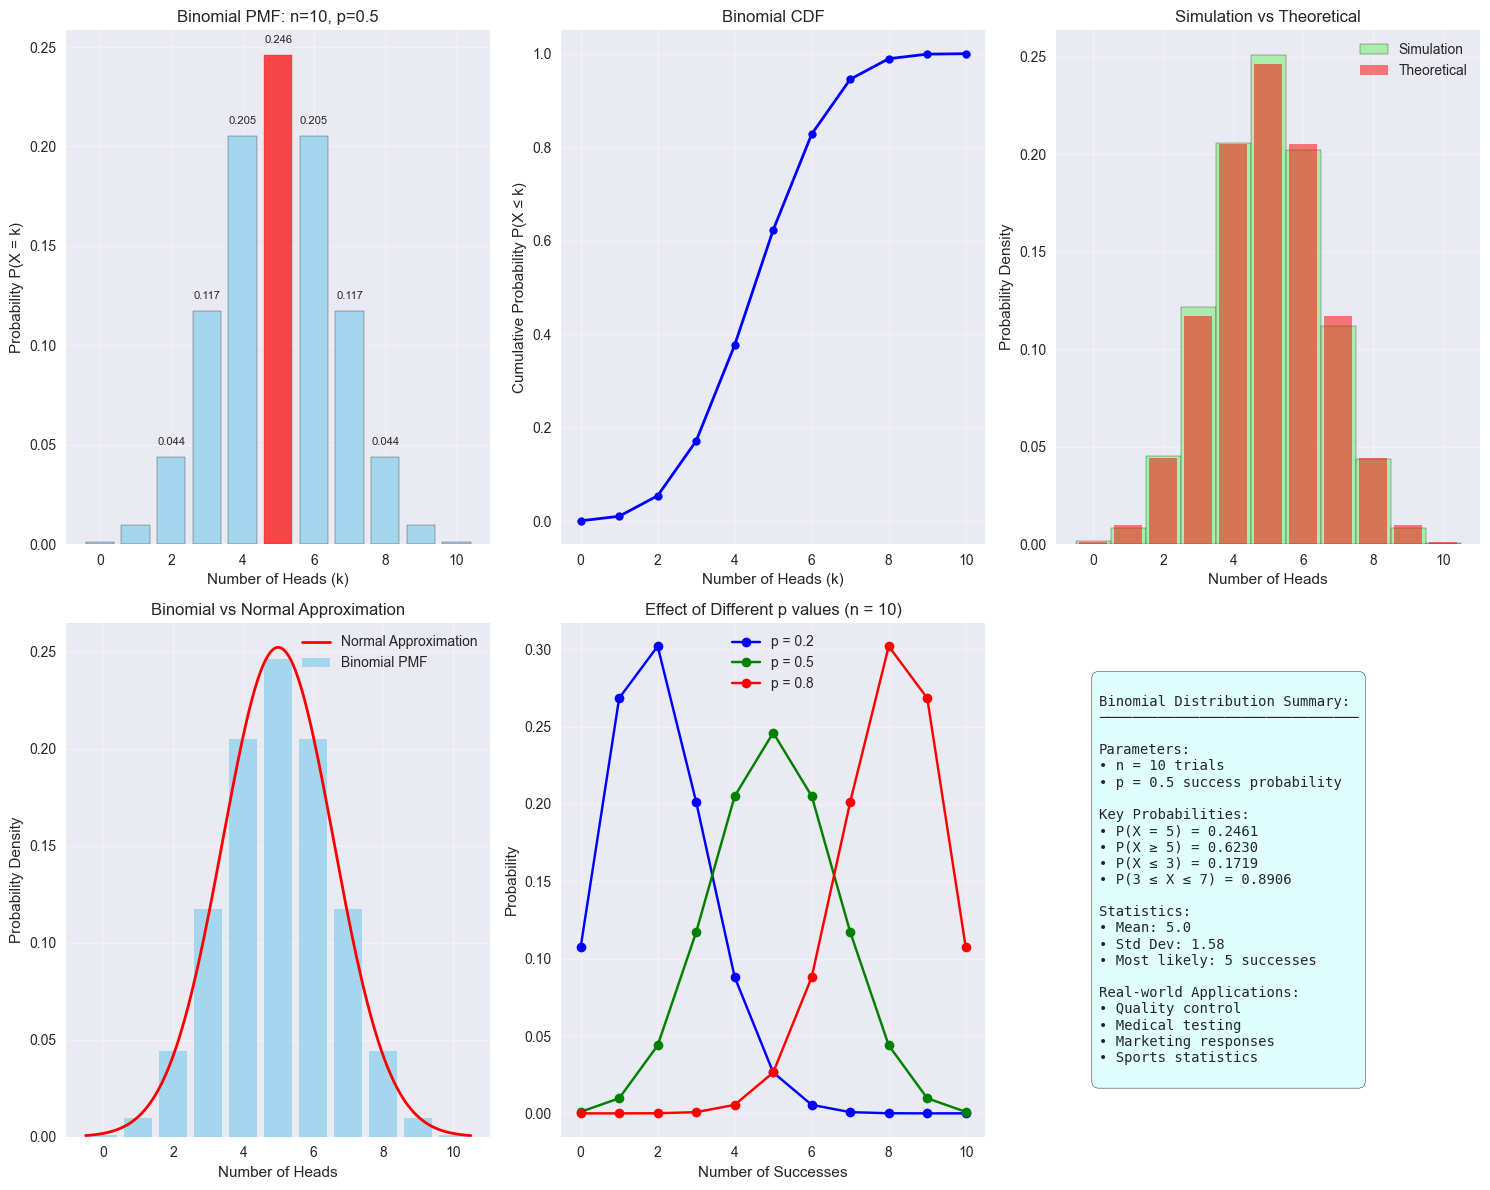


✅ Exercise 7 Complete: Binomial distribution analysis with comprehensive examples!


In [9]:


n = 10  # number of trials (coin flips)
p = 0.5  # probability of success (heads) on each trial

print(f"Binomial Distribution Parameters:")
print(f"Number of trials (n): {n}")
print(f"Probability of success (p): {p}")
print(f"Example: {n} coin flips, P(heads) = {p}")

# Calculate probability of exactly 5 heads in 10 flips
target_successes = 5
prob_exact_5 = binom.pmf(target_successes, n, p)

print(f"\n=== MAIN CALCULATION ===")
print(f"P(exactly {target_successes} heads in {n} flips) = {prob_exact_5:.6f}")
print(f"As percentage: {prob_exact_5*100:.2f}%")

# Calculate various probabilities
print(f"\n=== COMPREHENSIVE PROBABILITY ANALYSIS ===")

# Probabilities for different numbers of successes
print(f"Probability Mass Function (PMF):")
for k in range(n + 1):
    prob_k = binom.pmf(k, n, p)
    print(f"  P(X = {k:2d}) = {prob_k:.6f} ({prob_k*100:5.2f}%)")

# Cumulative probabilities
print(f"\nCumulative Distribution Function (CDF):")
for k in range(n + 1):
    prob_k_or_less = binom.cdf(k, n, p)
    print(f"  P(X ≤ {k:2d}) = {prob_k_or_less:.6f} ({prob_k_or_less*100:5.2f}%)")

# Common probability questions
print(f"\n=== COMMON PROBABILITY QUESTIONS ===")

# 1. At least 5 heads
prob_at_least_5 = 1 - binom.cdf(4, n, p)  # P(X ≥ 5) = 1 - P(X ≤ 4)
print(f"1. P(at least 5 heads) = P(X ≥ 5) = {prob_at_least_5:.6f}")

# 2. At most 3 heads
prob_at_most_3 = binom.cdf(3, n, p)
print(f"2. P(at most 3 heads) = P(X ≤ 3) = {prob_at_most_3:.6f}")

# 3. Between 3 and 7 heads (inclusive)
prob_between_3_7 = binom.cdf(7, n, p) - binom.cdf(2, n, p)
print(f"3. P(3 ≤ X ≤ 7) = {prob_between_3_7:.6f}")

# 4. More than 8 heads
prob_more_than_8 = 1 - binom.cdf(8, n, p)
print(f"4. P(more than 8 heads) = P(X > 8) = {prob_more_than_8:.6f}")

# 5. Fewer than 2 heads
prob_fewer_than_2 = binom.cdf(1, n, p)
print(f"5. P(fewer than 2 heads) = P(X < 2) = {prob_fewer_than_2:.6f}")

# Distribution statistics
mean = binom.mean(n, p)
var = binom.var(n, p)
std = binom.std(n, p)

print(f"\n=== DISTRIBUTION STATISTICS ===")
print(f"Mean (μ): {mean:.2f}")
print(f"Variance (σ²): {var:.2f}")
print(f"Standard Deviation (σ): {std:.2f}")
print(f"Expected value interpretation: On average, we expect {mean} heads in {n} flips")

# Compare with normal approximation
print(f"\n=== NORMAL APPROXIMATION ===")
print(f"For large n, binomial approaches normal distribution")
print(f"Normal approximation: N({mean}, {var:.2f})")

# Check continuity correction
prob_exact_5_normal = norm.pdf(5, mean, std)
prob_5_with_correction = norm.cdf(5.5, mean, std) - norm.cdf(4.5, mean, std)

print(f"Exact binomial P(X = 5): {prob_exact_5:.6f}")
print(f"Normal approx P(X = 5): {prob_exact_5_normal:.6f}")
print(f"Normal with continuity correction: {prob_5_with_correction:.6f}")

# Generate random samples
np.random.seed(42)
samples = binom.rvs(n, p, size=10000)

print(f"\n=== SIMULATION VERIFICATION ===")
print(f"Generated 10,000 random samples:")
print(f"Sample mean: {np.mean(samples):.3f} (theoretical: {mean})")
print(f"Sample std: {np.std(samples, ddof=1):.3f} (theoretical: {std:.3f})")
print(f"Sample P(X = 5): {np.mean(samples == 5):.6f} (theoretical: {prob_exact_5:.6f})")

# Different scenarios with different parameters
print(f"\n=== DIFFERENT SCENARIOS ===")
scenarios = [
    (20, 0.3, "20 free throws, 30% success rate"),
    (100, 0.1, "100 quality checks, 10% defect rate"),
    (50, 0.8, "50 multiple choice questions, 80% knowledge"),
    (15, 0.6, "15 sales calls, 60% conversion rate")
]

for n_scenario, p_scenario, description in scenarios:
    mean_scenario = n_scenario * p_scenario
    std_scenario = np.sqrt(n_scenario * p_scenario * (1 - p_scenario))
    print(f"\nScenario: {description}")
    print(f"  Parameters: n={n_scenario}, p={p_scenario}")
    print(f"  Expected successes: {mean_scenario:.1f} ± {std_scenario:.1f}")
    
    # Most likely outcome
    most_likely = int(np.round(mean_scenario))
    prob_most_likely = binom.pmf(most_likely, n_scenario, p_scenario)
    print(f"  Most likely outcome: {most_likely} successes (P = {prob_most_likely:.4f})")

# Visualization
plt.figure(figsize=(15, 12))

# Subplot 1: PMF bar chart
plt.subplot(2, 3, 1)
k_values = np.arange(0, n + 1)
pmf_values = binom.pmf(k_values, n, p)

bars = plt.bar(k_values, pmf_values, alpha=0.7, color='skyblue', edgecolor='black')
bars[target_successes].set_color('red')  # Highlight the target value

plt.xlabel('Number of Heads (k)')
plt.ylabel('Probability P(X = k)')
plt.title(f'Binomial PMF: n={n}, p={p}')
plt.grid(True, alpha=0.3)

# Add value labels
for i, (k, prob) in enumerate(zip(k_values, pmf_values)):
    if prob > 0.01:  # Only label significant probabilities
        plt.text(k, prob + 0.005, f'{prob:.3f}', ha='center', va='bottom', fontsize=8)

# Subplot 2: CDF
plt.subplot(2, 3, 2)
cdf_values = binom.cdf(k_values, n, p)
plt.plot(k_values, cdf_values, 'bo-', linewidth=2, markersize=6)
plt.xlabel('Number of Heads (k)')
plt.ylabel('Cumulative Probability P(X ≤ k)')
plt.title('Binomial CDF')
plt.grid(True, alpha=0.3)

# Subplot 3: Simulation histogram
plt.subplot(2, 3, 3)
plt.hist(samples, bins=np.arange(-0.5, n+1.5, 1), density=True, alpha=0.7, 
         color='lightgreen', edgecolor='black', label='Simulation')
plt.bar(k_values, pmf_values, alpha=0.5, color='red', label='Theoretical')
plt.xlabel('Number of Heads')
plt.ylabel('Probability Density')
plt.title('Simulation vs Theoretical')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 4: Normal approximation comparison
plt.subplot(2, 3, 4)
x_norm = np.linspace(-0.5, n+0.5, 1000)
y_norm = norm.pdf(x_norm, mean, std)

plt.bar(k_values, pmf_values, alpha=0.7, color='skyblue', label='Binomial PMF')
plt.plot(x_norm, y_norm, 'r-', linewidth=2, label='Normal Approximation')
plt.xlabel('Number of Heads')
plt.ylabel('Probability Density')
plt.title('Binomial vs Normal Approximation')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 5: Different p values comparison
plt.subplot(2, 3, 5)
p_values = [0.2, 0.5, 0.8]
colors = ['blue', 'green', 'red']

for p_comp, color in zip(p_values, colors):
    pmf_comp = binom.pmf(k_values, n, p_comp)
    plt.plot(k_values, pmf_comp, 'o-', color=color, label=f'p = {p_comp}')

plt.xlabel('Number of Successes')
plt.ylabel('Probability')
plt.title(f'Effect of Different p values (n = {n})')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 6: Probability summary table
plt.subplot(2, 3, 6)
plt.axis('off')
summary_text = f"""
Binomial Distribution Summary:
───────────────────────────────

Parameters:
• n = {n} trials
• p = {p} success probability

Key Probabilities:
• P(X = {target_successes}) = {prob_exact_5:.4f}
• P(X ≥ 5) = {prob_at_least_5:.4f}
• P(X ≤ 3) = {prob_at_most_3:.4f}
• P(3 ≤ X ≤ 7) = {prob_between_3_7:.4f}

Statistics:
• Mean: {mean:.1f}
• Std Dev: {std:.2f}
• Most likely: {int(np.round(mean))} successes

Real-world Applications:
• Quality control
• Medical testing
• Marketing responses
• Sports statistics
"""

plt.text(0.1, 0.5, summary_text, fontsize=10, fontfamily='monospace',
         verticalalignment='center', bbox=dict(boxstyle="round,pad=0.5", facecolor="lightcyan"))

plt.tight_layout()
plt.show()

print(f"\n✅ Exercise 7 Complete: Binomial distribution analysis with comprehensive examples!")

##  Exercise 8: Correlation Coefficients



=== CREATING SAMPLE DATASETS ===
Created 5 different datasets with varying correlation patterns

=== PEARSON CORRELATION ANALYSIS ===
Pearson measures linear relationships (-1 to +1)

Dataset 1: Strong Positive Linear
  Pearson r = 0.9655
  P-value = 0.000000
  Significance: ***
  Interpretation: Very Strong Positive linear relationship

Dataset 2: Strong Negative Linear
  Pearson r = -0.9650
  P-value = 0.000000
  Significance: ***
  Interpretation: Very Strong Negative linear relationship

Dataset 3: Nonlinear (Quadratic)
  Pearson r = 0.9619
  P-value = 0.000000
  Significance: ***
  Interpretation: Very Strong Positive linear relationship

Dataset 4: No Correlation
  Pearson r = -0.0568
  P-value = 0.574568
  Significance: ns
  Interpretation: Very Weak Negative linear relationship

Dataset 5: Perfect Linear
  Pearson r = 1.0000
  P-value = 0.000000
  Significance: ***
  Interpretation: Very Strong Positive linear relationship

=== SPEARMAN CORRELATION ANALYSIS ===
Spearman measure

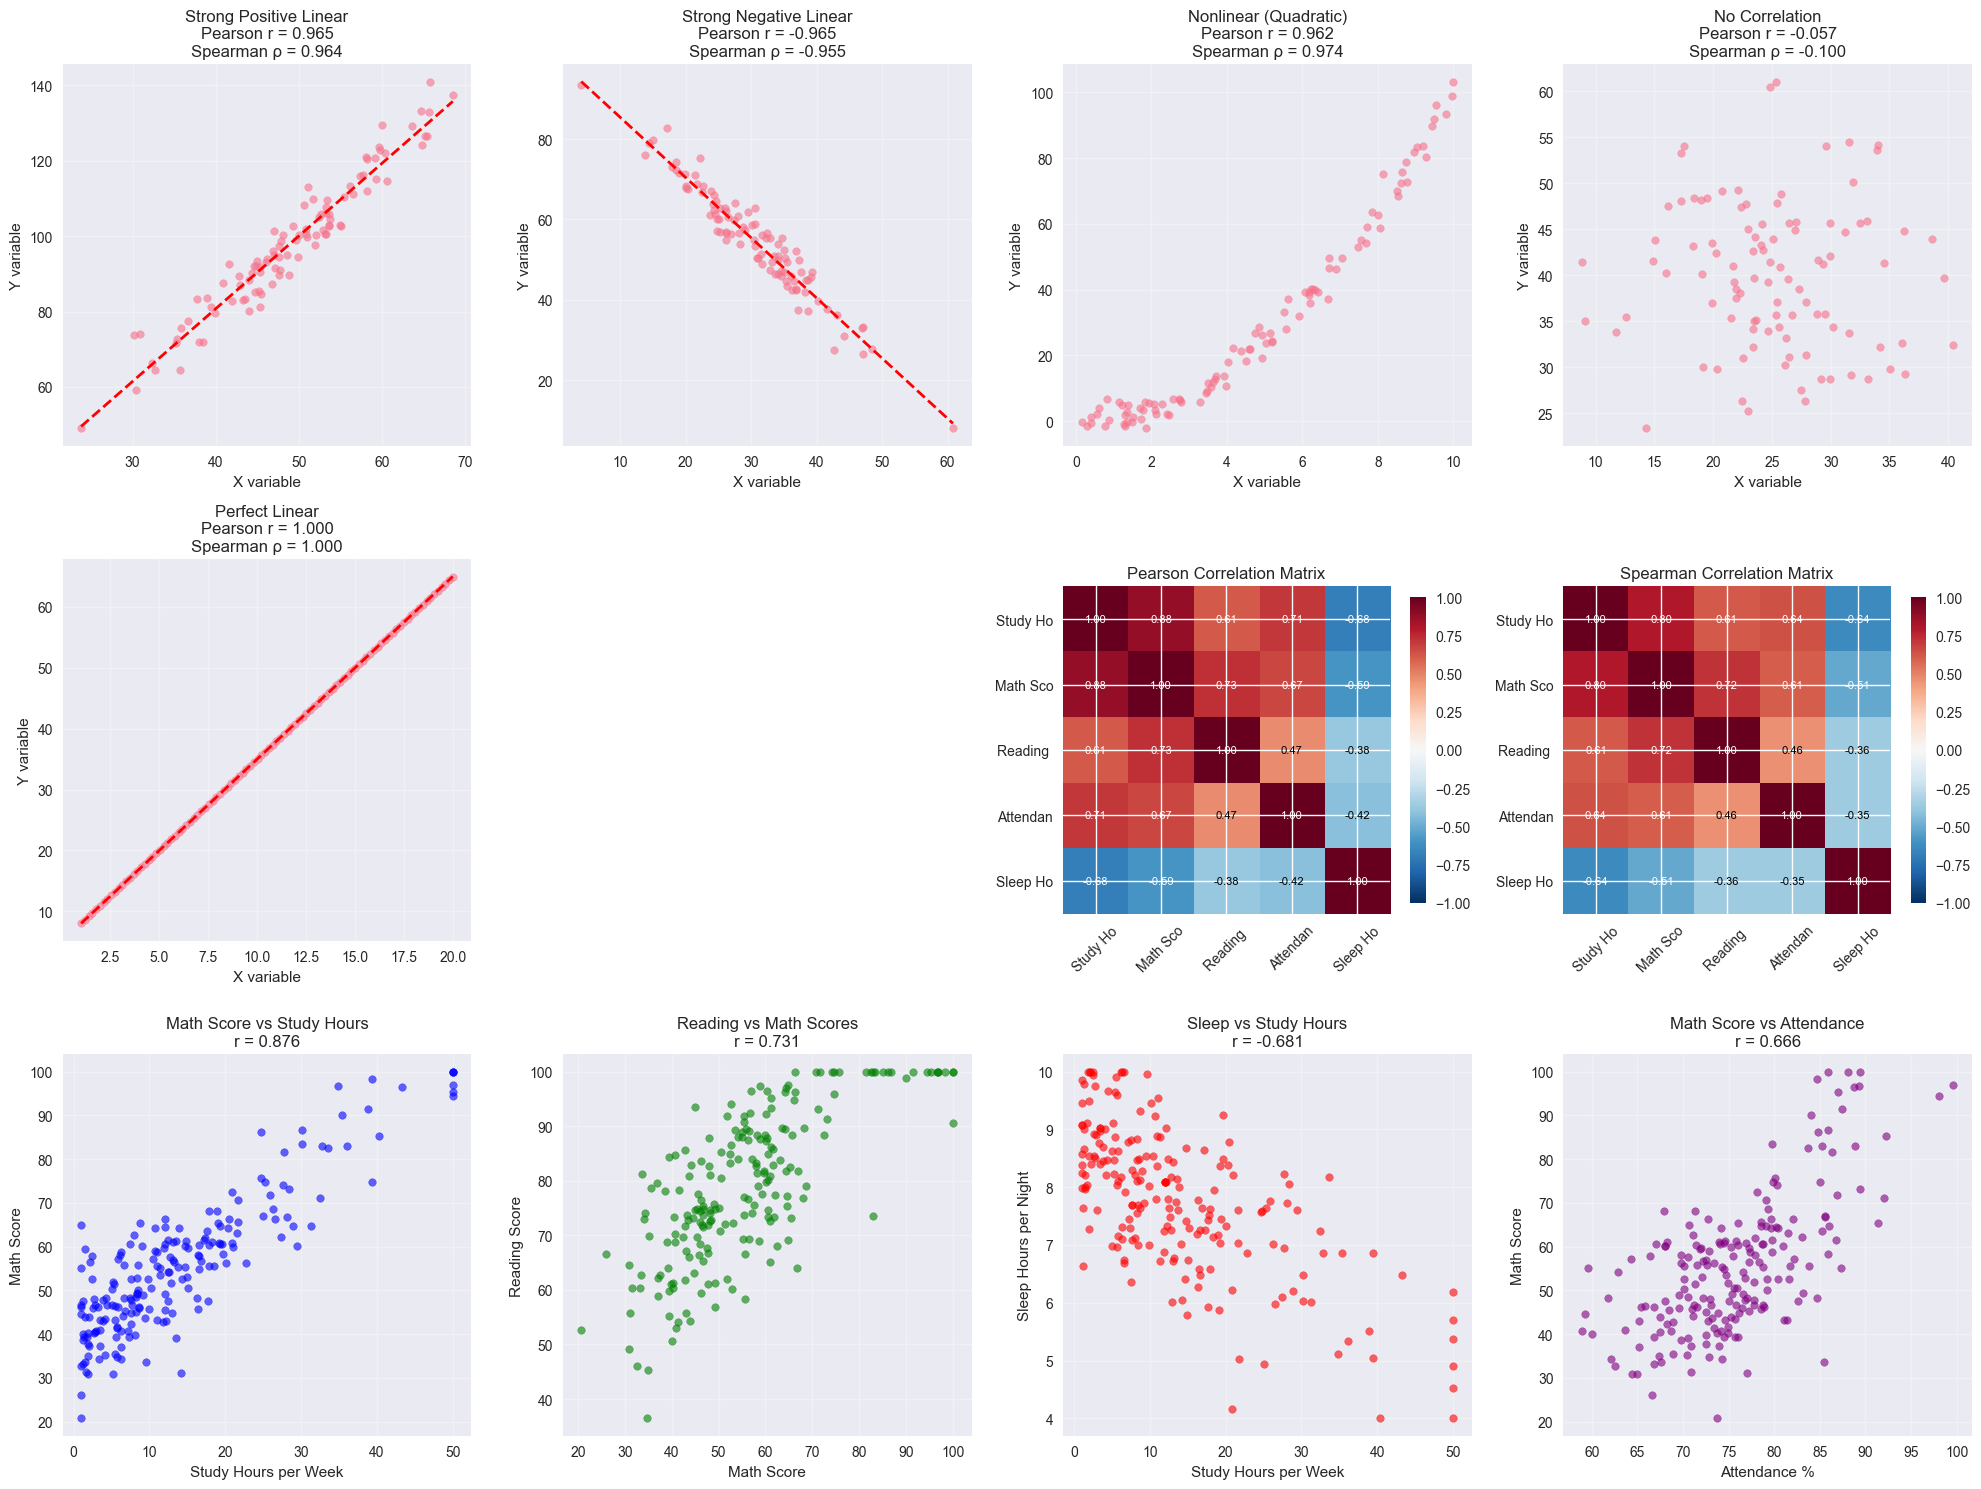


 Exercise 8 Complete: Comprehensive correlation analysis with multiple examples!


In [10]:


# Create sample datasets with different correlation patterns
np.random.seed(42)
n_samples = 100

print("=== CREATING SAMPLE DATASETS ===")

# Dataset 1: Strong positive linear correlation
x1 = np.random.normal(50, 10, n_samples)
y1 = 2 * x1 + np.random.normal(0, 5, n_samples)  # y = 2x + noise

# Dataset 2: Strong negative linear correlation
x2 = np.random.normal(30, 8, n_samples)
y2 = -1.5 * x2 + 100 + np.random.normal(0, 4, n_samples)  # y = -1.5x + 100 + noise

# Dataset 3: Nonlinear but monotonic relationship
x3 = np.random.uniform(0, 10, n_samples)
y3 = x3**2 + np.random.normal(0, 3, n_samples)  # Quadratic relationship

# Dataset 4: No correlation
x4 = np.random.normal(25, 6, n_samples)
y4 = np.random.normal(40, 8, n_samples)  # Independent variables

# Dataset 5: Perfect linear correlation
x5 = np.linspace(1, 20, n_samples)
y5 = 3 * x5 + 5  # Perfect linear: y = 3x + 5

print(f"Created {len([x1, x2, x3, x4, x5])} different datasets with varying correlation patterns")

# Calculate Pearson correlation coefficients
print(f"\n=== PEARSON CORRELATION ANALYSIS ===")
print("Pearson measures linear relationships (-1 to +1)")

datasets = [
    (x1, y1, "Strong Positive Linear"),
    (x2, y2, "Strong Negative Linear"), 
    (x3, y3, "Nonlinear (Quadratic)"),
    (x4, y4, "No Correlation"),
    (x5, y5, "Perfect Linear")
]

pearson_results = []

for i, (x, y, description) in enumerate(datasets, 1):
    # Calculate Pearson correlation
    r_pearson, p_value_pearson = pearsonr(x, y)
    pearson_results.append((r_pearson, p_value_pearson))
    
    print(f"\nDataset {i}: {description}")
    print(f"  Pearson r = {r_pearson:.4f}")
    print(f"  P-value = {p_value_pearson:.6f}")
    print(f"  Significance: {'***' if p_value_pearson < 0.001 else '**' if p_value_pearson < 0.01 else '*' if p_value_pearson < 0.05 else 'ns'}")
    
    # Interpret correlation strength
    abs_r = abs(r_pearson)
    if abs_r >= 0.9:
        strength = "Very Strong"
    elif abs_r >= 0.7:
        strength = "Strong"
    elif abs_r >= 0.5:
        strength = "Moderate"
    elif abs_r >= 0.3:
        strength = "Weak"
    else:
        strength = "Very Weak"
    
    direction = "Positive" if r_pearson > 0 else "Negative" if r_pearson < 0 else "None"
    print(f"  Interpretation: {strength} {direction} linear relationship")

# Calculate Spearman correlation coefficients
print(f"\n=== SPEARMAN CORRELATION ANALYSIS ===")
print("Spearman measures monotonic relationships (rank-based)")

spearman_results = []

for i, (x, y, description) in enumerate(datasets, 1):
    # Calculate Spearman correlation
    rho_spearman, p_value_spearman = spearmanr(x, y)
    spearman_results.append((rho_spearman, p_value_spearman))
    
    print(f"\nDataset {i}: {description}")
    print(f"  Spearman ρ = {rho_spearman:.4f}")
    print(f"  P-value = {p_value_spearman:.6f}")
    print(f"  Significance: {'***' if p_value_spearman < 0.001 else '**' if p_value_spearman < 0.01 else '*' if p_value_spearman < 0.05 else 'ns'}")
    
    # Interpret correlation strength
    abs_rho = abs(rho_spearman)
    if abs_rho >= 0.9:
        strength = "Very Strong"
    elif abs_rho >= 0.7:
        strength = "Strong"
    elif abs_rho >= 0.5:
        strength = "Moderate"
    elif abs_rho >= 0.3:
        strength = "Weak"
    else:
        strength = "Very Weak"
    
    direction = "Positive" if rho_spearman > 0 else "Negative" if rho_spearman < 0 else "None"
    print(f"  Interpretation: {strength} {direction} monotonic relationship")

# Comparison between Pearson and Spearman
print(f"\n=== PEARSON vs SPEARMAN COMPARISON ===")

for i, (description) in enumerate([desc for _, _, desc in datasets], 1):
    r_pearson = pearson_results[i-1][0]
    rho_spearman = spearman_results[i-1][0]
    difference = abs(r_pearson - rho_spearman)
    
    print(f"\nDataset {i}: {description}")
    print(f"  Pearson r:  {r_pearson:7.4f}")
    print(f"  Spearman ρ: {rho_spearman:7.4f}")
    print(f"  Difference: {difference:7.4f}")
    
    if difference < 0.1:
        comparison = "Very similar - likely linear relationship"
    elif difference < 0.2:
        comparison = "Somewhat different - possible nonlinear components"
    else:
        comparison = "Very different - strong nonlinear relationship"
    
    print(f"  Analysis: {comparison}")

# Real-world example with multi-variable correlation matrix
print(f"\n=== REAL-WORLD EXAMPLE: STUDENT PERFORMANCE DATA ===")

# Simulate realistic student data
np.random.seed(123)
n_students = 200

# Create correlated variables
study_hours = np.random.exponential(15, n_students)  # Study hours per week
study_hours = np.clip(study_hours, 1, 50)  # Realistic range

# Math score influenced by study hours + some randomness
math_score = 40 + 1.2 * study_hours + np.random.normal(0, 8, n_students)
math_score = np.clip(math_score, 0, 100)

# Reading score correlated with math but with different pattern
reading_score = 35 + 0.8 * math_score + np.random.normal(0, 10, n_students)
reading_score = np.clip(reading_score, 0, 100)

# Attendance rate (percentage)
attendance = 70 + 0.4 * study_hours + np.random.normal(0, 5, n_students)
attendance = np.clip(attendance, 40, 100)

# Sleep hours (inversely related to study hours)
sleep_hours = 9 - 0.08 * study_hours + np.random.normal(0, 1, n_students)
sleep_hours = np.clip(sleep_hours, 4, 10)

# Create correlation matrix
variables = {
    'Study Hours': study_hours,
    'Math Score': math_score, 
    'Reading Score': reading_score,
    'Attendance %': attendance,
    'Sleep Hours': sleep_hours
}

var_names = list(variables.keys())
n_vars = len(var_names)

print(f"Variables: {', '.join(var_names)}")
print(f"Sample size: {n_students} students")

# Calculate correlation matrices
pearson_matrix = np.zeros((n_vars, n_vars))
spearman_matrix = np.zeros((n_vars, n_vars))
p_value_matrix = np.zeros((n_vars, n_vars))

print(f"\n=== CORRELATION MATRIX (Pearson) ===")
print(f"{'Variable':<15}", end="")
for name in var_names:
    print(f"{name[:10]:>12}", end="")
print()

for i, name1 in enumerate(var_names):
    print(f"{name1:<15}", end="")
    for j, name2 in enumerate(var_names):
        if i == j:
            pearson_matrix[i, j] = 1.0
            spearman_matrix[i, j] = 1.0
            p_value_matrix[i, j] = 0.0
            print(f"{'1.0000':>12}", end="")
        else:
            r, p = pearsonr(variables[name1], variables[name2])
            rho, _ = spearmanr(variables[name1], variables[name2])
            pearson_matrix[i, j] = r
            spearman_matrix[i, j] = rho
            p_value_matrix[i, j] = p
            print(f"{r:>12.4f}", end="")
    print()

print(f"\n=== CORRELATION MATRIX (Spearman) ===")
print(f"{'Variable':<15}", end="")
for name in var_names:
    print(f"{name[:10]:>12}", end="")
print()

for i, name1 in enumerate(var_names):
    print(f"{name1:<15}", end="")
    for j, name2 in enumerate(var_names):
        print(f"{spearman_matrix[i, j]:>12.4f}", end="")
    print()

# Find strongest correlations
print(f"\n=== STRONGEST CORRELATIONS ===")
correlations = []
for i in range(n_vars):
    for j in range(i+1, n_vars):
        correlations.append((
            var_names[i], var_names[j], 
            pearson_matrix[i, j], spearman_matrix[i, j],
            p_value_matrix[i, j]
        ))

# Sort by absolute Pearson correlation
correlations.sort(key=lambda x: abs(x[2]), reverse=True)

for var1, var2, r, rho, p in correlations:
    significance = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"{var1} ↔ {var2}:")
    print(f"  Pearson: {r:6.3f} {significance}")
    print(f"  Spearman: {rho:6.3f}")

# Statistical interpretation guide
print(f"\n=== INTERPRETATION GUIDE ===")
interpretation_guide = """
Correlation Coefficient Interpretation:
────────────────────────────────────────

Strength of Relationship:
• |r| ≥ 0.9  : Very Strong
• |r| ≥ 0.7  : Strong  
• |r| ≥ 0.5  : Moderate
• |r| ≥ 0.3  : Weak
• |r| < 0.3  : Very Weak

Direction:
• r > 0 : Positive (as X increases, Y increases)
• r < 0 : Negative (as X increases, Y decreases)
• r = 0 : No linear relationship

Pearson vs Spearman:
• Similar values → Linear relationship
• Different values → Nonlinear relationship
• Spearman > Pearson → Monotonic but not linear

Statistical Significance:
• p < 0.001 : *** (highly significant)
• p < 0.01  : ** (significant)  
• p < 0.05  : * (marginally significant)
• p ≥ 0.05  : ns (not significant)

Important Notes:
• Correlation ≠ Causation
• Outliers can affect Pearson more than Spearman
• Sample size affects significance testing
"""

print(interpretation_guide)

plt.figure(figsize=(20, 15))

# Plot individual datasets
for i, (x, y, description) in enumerate(datasets, 1):
    plt.subplot(3, 4, i)
    plt.scatter(x, y, alpha=0.6, s=30)
    
    # Add trend line for linear relationships
    if i in [1, 2, 5]:  # Linear relationships
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        x_trend = np.linspace(min(x), max(x), 100)
        plt.plot(x_trend, p(x_trend), 'r--', linewidth=2)
    
    r_pearson = pearson_results[i-1][0]
    rho_spearman = spearman_results[i-1][0]
    
    plt.title(f'{description}\nPearson r = {r_pearson:.3f}\nSpearman ρ = {rho_spearman:.3f}')
    plt.xlabel('X variable')
    plt.ylabel('Y variable')
    plt.grid(True, alpha=0.3)

# Correlation matrix heatmap (Pearson)
plt.subplot(3, 4, 7)
im1 = plt.imshow(pearson_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.title('Pearson Correlation Matrix')
plt.xticks(range(n_vars), [name[:8] for name in var_names], rotation=45)
plt.yticks(range(n_vars), [name[:8] for name in var_names])

# Add correlation values to heatmap
for i in range(n_vars):
    for j in range(n_vars):
        plt.text(j, i, f'{pearson_matrix[i, j]:.2f}', 
                ha='center', va='center', fontsize=8,
                color='white' if abs(pearson_matrix[i, j]) > 0.5 else 'black')

plt.colorbar(im1, shrink=0.8)

# Correlation matrix heatmap (Spearman)
plt.subplot(3, 4, 8)
im2 = plt.imshow(spearman_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.title('Spearman Correlation Matrix')
plt.xticks(range(n_vars), [name[:8] for name in var_names], rotation=45)
plt.yticks(range(n_vars), [name[:8] for name in var_names])

# Add correlation values to heatmap
for i in range(n_vars):
    for j in range(n_vars):
        plt.text(j, i, f'{spearman_matrix[i, j]:.2f}', 
                ha='center', va='center', fontsize=8,
                color='white' if abs(spearman_matrix[i, j]) > 0.5 else 'black')

plt.colorbar(im2, shrink=0.8)

# Student data scatter plots
student_vars = list(variables.items())

# Math vs Study Hours
plt.subplot(3, 4, 9)
plt.scatter(study_hours, math_score, alpha=0.6, color='blue', s=30)
plt.xlabel('Study Hours per Week')
plt.ylabel('Math Score')
plt.title(f'Math Score vs Study Hours\nr = {pearsonr(study_hours, math_score)[0]:.3f}')
plt.grid(True, alpha=0.3)

# Reading vs Math
plt.subplot(3, 4, 10)
plt.scatter(math_score, reading_score, alpha=0.6, color='green', s=30)
plt.xlabel('Math Score')
plt.ylabel('Reading Score')
plt.title(f'Reading vs Math Scores\nr = {pearsonr(math_score, reading_score)[0]:.3f}')
plt.grid(True, alpha=0.3)

# Sleep vs Study Hours
plt.subplot(3, 4, 11)
plt.scatter(study_hours, sleep_hours, alpha=0.6, color='red', s=30)
plt.xlabel('Study Hours per Week')
plt.ylabel('Sleep Hours per Night')
plt.title(f'Sleep vs Study Hours\nr = {pearsonr(study_hours, sleep_hours)[0]:.3f}')
plt.grid(True, alpha=0.3)

# Attendance vs Math Score
plt.subplot(3, 4, 12)
plt.scatter(attendance, math_score, alpha=0.6, color='purple', s=30)
plt.xlabel('Attendance %')
plt.ylabel('Math Score')
plt.title(f'Math Score vs Attendance\nr = {pearsonr(attendance, math_score)[0]:.3f}')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Exercise 8 Complete: Comprehensive correlation analysis with multiple examples!")